# Reliability Diagram

/tmp/ipykernel_10064/2461680052.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


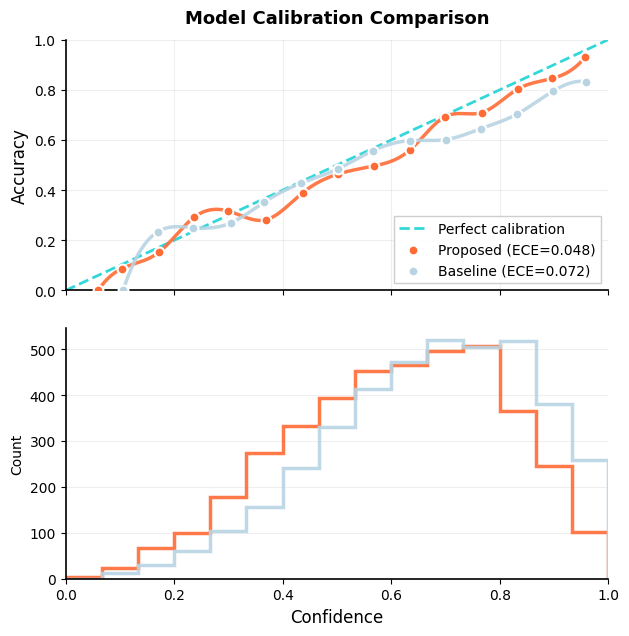

ECE scores: {'Proposed': 0.047767081227629946, 'Baseline': 0.07222852009369814}


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def _bin_stats(confidence, correct, bin_edges):
    """Return per-bin count, mean_conf, mean_acc (NaN for empty bins)."""
    confidence = np.asarray(confidence, dtype=np.float64)
    correct = np.asarray(correct, dtype=np.float64)

    n_bins = len(bin_edges) - 1
    bin_ids = np.clip(np.digitize(confidence, bin_edges, right=True) - 1, 0, n_bins - 1)

    cnt = np.zeros(n_bins, dtype=np.int64)
    mconf = np.zeros(n_bins, dtype=np.float64)
    macc = np.zeros(n_bins, dtype=np.float64)

    for b in range(n_bins):
        m = (bin_ids == b)
        c = int(m.sum())
        cnt[b] = c
        if c > 0:
            mconf[b] = confidence[m].mean()
            macc[b] = correct[m].mean()
        else:
            mconf[b] = 0.5 * (bin_edges[b] + bin_edges[b + 1])
            macc[b] = np.nan
    return cnt, mconf, macc

def _ece(cnt, mconf, macc):
    nonempty = cnt > 0
    if nonempty.sum() == 0:
        return np.nan
    w = cnt[nonempty] / cnt[nonempty].sum()
    return float(np.sum(w * np.abs(macc[nonempty] - mconf[nonempty])))

def reliability_diagram_multi(models, n_bins=15, title=None, save_path=None):
    """
    models: list of tuples -> (name, confidence[N], correct[N])
            confidence = max predicted prob per sample
            correct    = 1 if prediction correct else 0
    """
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    
    # Modern color scheme - one vibrant, one light
    colors = ['#FF6B35', '#B8D4E3']  # Vibrant orange, light blue
    
    fig = plt.figure(figsize=(7, 7))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.15)
    ax = fig.add_subplot(gs[0])
    axh = fig.add_subplot(gs[1], sharex=ax)

    # Perfect calibration line - aquatic blue
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, color='#00CED1', 
            label="Perfect calibration", alpha=0.8, zorder=1)

    eces = {}

    for i, (name, conf, corr) in enumerate(models):
        cnt, mconf, macc = _bin_stats(conf, corr, bin_edges)
        ece = _ece(cnt, mconf, macc)
        eces[name] = ece

        nonempty = cnt > 0
        mconf_nonempty = mconf[nonempty]
        macc_nonempty = macc[nonempty]
        
        # Smooth interpolation for seamless curve
        from scipy.interpolate import make_interp_spline
        if len(mconf_nonempty) >= 4:  # Need at least 4 points for cubic spline
            # Create smooth curve
            spl = make_interp_spline(mconf_nonempty, macc_nonempty, k=3)
            mconf_smooth = np.linspace(mconf_nonempty.min(), mconf_nonempty.max(), 300)
            macc_smooth = spl(mconf_smooth)
            
            # Plot smooth curve
            ax.plot(
                mconf_smooth,
                macc_smooth,
                linestyle='-',
                linewidth=2.5,
                color=colors[i],
                alpha=0.9,
                zorder=2
            )
            
            # Plot original points as dots
            ax.scatter(
                mconf_nonempty,
                macc_nonempty,
                s=50,
                color=colors[i],
                label=f"{name} (ECE={ece:.3f})",
                edgecolors='white',
                linewidths=1.5,
                zorder=3
            )
        else:
            # Fallback for few points
            ax.plot(
                mconf_nonempty,
                macc_nonempty,
                marker='o',
                linestyle='-',
                linewidth=2.5,
                markersize=7,
                color=colors[i],
                label=f"{name} (ECE={ece:.3f})",
                markeredgecolor='white',
                markeredgewidth=1.5,
                zorder=3
            )

        # Histogram with lines instead of filled areas
        axh.hist(
            np.asarray(conf, dtype=np.float64),
            bins=bin_edges,
            histtype="step",
            linewidth=2.5,
            color=colors[i],
            alpha=0.9,
            label=name,
        )

    # Top panel styling
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy", fontsize=12, fontweight='500')
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.legend(frameon=True, loc="lower right", fontsize=10, 
             fancybox=False, shadow=False, framealpha=0.95)
    if title:
        ax.set_title(title, pad=12, fontsize=13, fontweight='600')
    plt.setp(ax.get_xticklabels(), visible=False)
    ax.tick_params(axis='both', which='major', labelsize=10)

    # Bottom panel styling
    axh.set_xlabel("Confidence", fontsize=12, fontweight='500')
    axh.set_ylabel("Count", fontsize=10, fontweight='500')
    axh.grid(True, alpha=0.2, axis='y', linestyle='-', linewidth=0.8)
    axh.spines["top"].set_visible(False)
    axh.spines["right"].set_visible(False)
    axh.spines["left"].set_linewidth(1.2)
    axh.spines["bottom"].set_linewidth(1.2)
    axh.tick_params(axis='both', which='major', labelsize=10)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)
    return fig, eces


# ------------------ Demo with 2 models ------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    N = 4000

    # Model A: Proposed (better calibrated)
    conf_A = rng.beta(3.2, 2.0, size=N)
    accp_A = np.clip(conf_A - 0.03, 0, 1)
    corr_A = (rng.random(N) < accp_A).astype(np.float64)

    # Model B: Baseline (overconfident)
    conf_B = rng.beta(3.5, 1.7, size=N)
    accp_B = np.clip(conf_B - 0.12 * (conf_B > 0.65), 0, 1)
    corr_B = (rng.random(N) < accp_B).astype(np.float64)

    models = [
        ("Proposed", conf_A, corr_A),
        ("Baseline", conf_B, corr_B),
    ]

    fig, eces = reliability_diagram_multi(
        models, n_bins=15, 
        title="Model Calibration Comparison", 
        save_path="reliability_diagram.pdf"
    )
    plt.show()
    print("ECE scores:", eces)

Saved pooled bins:
   /home/nirob/Desktop/Brain tumor mri /plots/T1C+/Proposed_calibration_bin.csv
   /home/nirob/Desktop/Brain tumor mri /plots/T1C+/Xception41_calibration_bin.csv


/tmp/ipykernel_10064/2405815907.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


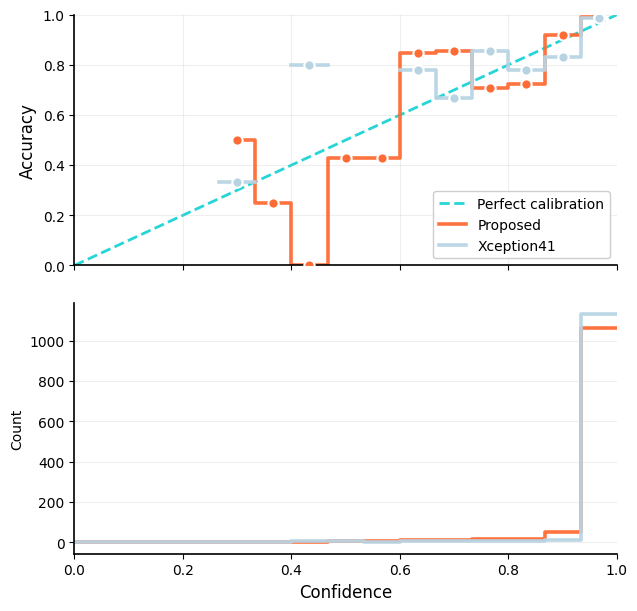

ECE: {'Proposed': 0.012609326202070923, 'Xception41': 0.013295865024042453}
Figure saved -> /home/nirob/Desktop/Brain tumor mri /plots/T1C+/reliability_T1C+_proposed_vs_densenet.png


In [21]:
# ============================================================
# RELIABILITY DIAGRAM (2 MODELS) FROM *_VAL_calibration_bins.csv
# - Works even if the two CSVs use different column names:
#   DenseNet:  bin lower upper count avg_conf avg_acc abs_gap
#   Proposed:  bin lo    hi    count bin_conf bin_acc gap
#
# - Supports pooling multiple seeds into ONE calibration table per model
#   (count-weighted pooling).
#
# - Plots a proper reliability diagram (STEP + POINTS on BIN CENTERS)
#   + bottom panel histogram from BIN COUNTS (no raw conf needed).
#
# Dependencies: numpy, pandas, matplotlib
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------ USER INPUT ------------------
PROPOSED_CSVS = [
    r"/home/nirob/Desktop/Brain tumor mri /runs/Proposed Model/T1C+/seed0/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed0_VAL_calibration_bins.csv",
    r"/home/nirob/Desktop/Brain tumor mri /runs/Proposed Model/T1C+/seed24/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed24_VAL_calibration_bins.csv",
    r"/home/nirob/Desktop/Brain tumor mri /runs/Proposed Model/T1C+/seed48/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed48_VAL_calibration_bins.csv"
]

DENSENET_CSVS = [
    r"/home/nirob/Desktop/Brain tumor mri /benchmark_outputs_timm_q1 V1/T1C+/Xception41/seed_0/Xception41_seed0_VAL_calibration_bins.csv",
    r"/home/nirob/Desktop/Brain tumor mri /benchmark_outputs_timm_q1/T1C+/Xception41/seed_48/Xception41_seed48_VAL_calibration_bins.csv",
    r"/home/nirob/Desktop/Brain tumor mri /benchmark_outputs_timm_q1/T1C+/Xception41/seed_24/Xception41_seed24_VAL_calibration_bins.csv"
]
Modality_NAME = "T1C+"
SAVE_DIR = r"/home/nirob/Desktop/Brain tumor mri /plots/T1C+"
FIG_NAME = f"reliability_{Modality_NAME}_proposed_vs_densenet.png"   # or .pdf

TITLE = f"Model Calibration Comparison ({Modality_NAME}, 15 bins)"

MODEL_A_NAME = "Proposed"
MODEL_B_NAME = "Xception41"
# ------------------------------------------------


def _read_csv_auto(path: str) -> pd.DataFrame:
    # auto-detect delimiter (tab/comma)
    return pd.read_csv(path, sep=None, engine="python")


def _normalize_bins_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize columns to:
      bin, lower, upper, count, avg_conf, avg_acc, abs_gap
    Accepts either DenseNet-style or Proposed-style naming.
    """
    colmap = {}

    # bin index
    if "bin" in df.columns:
        colmap["bin"] = "bin"

    # edges
    if "lower" in df.columns and "upper" in df.columns:
        colmap["lower"] = "lower"
        colmap["upper"] = "upper"
    elif "lo" in df.columns and "hi" in df.columns:
        colmap["lower"] = "lo"
        colmap["upper"] = "hi"
    else:
        raise ValueError(f"Could not find bin edge columns in: {list(df.columns)}")

    # count
    if "count" in df.columns:
        colmap["count"] = "count"
    else:
        raise ValueError(f"Could not find 'count' column in: {list(df.columns)}")

    # confidence
    if "avg_conf" in df.columns:
        colmap["avg_conf"] = "avg_conf"
    elif "bin_conf" in df.columns:
        colmap["avg_conf"] = "bin_conf"
    else:
        raise ValueError(f"Could not find confidence column in: {list(df.columns)}")

    # accuracy
    if "avg_acc" in df.columns:
        colmap["avg_acc"] = "avg_acc"
    elif "bin_acc" in df.columns:
        colmap["avg_acc"] = "bin_acc"
    else:
        raise ValueError(f"Could not find accuracy column in: {list(df.columns)}")

    # gap (optional)
    if "abs_gap" in df.columns:
        colmap["abs_gap"] = "abs_gap"
    elif "gap" in df.columns:
        colmap["abs_gap"] = "gap"
    else:
        # will be computed later
        pass

    out = pd.DataFrame({
        "bin": df[colmap["bin"]] if "bin" in colmap else np.arange(len(df)),
        "lower": df[colmap["lower"]],
        "upper": df[colmap["upper"]],
        "count": df[colmap["count"]],
        "avg_conf": df[colmap["avg_conf"]],
        "avg_acc": df[colmap["avg_acc"]],
    })

    # ensure numeric
    for c in ["bin", "lower", "upper", "count", "avg_conf", "avg_acc"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.sort_values("bin").reset_index(drop=True)

    # compute abs_gap if missing or NaN
    out["abs_gap"] = np.abs(out["avg_acc"] - out["avg_conf"])
    return out


def _pool_bins(seed_csv_paths) -> pd.DataFrame:
    """
    Count-weighted pooling across multiple seeds:
      count = sum(count_s)
      avg_conf = sum(count_s * avg_conf_s) / sum(count_s)
      avg_acc  = sum(count_s * avg_acc_s ) / sum(count_s)
    """
    dfs = []
    for p in seed_csv_paths:
        df = _normalize_bins_df(_read_csv_auto(p))
        dfs.append(df)

    base = dfs[0][["bin", "lower", "upper"]].copy()

    # check identical edges
    for i, d in enumerate(dfs[1:], start=1):
        if (not np.allclose(d["lower"].to_numpy(), base["lower"].to_numpy())) or \
           (not np.allclose(d["upper"].to_numpy(), base["upper"].to_numpy())):
            raise ValueError(f"Bin edges mismatch between seed0 and seed{i}. Recompute with same binning.")

    counts = np.stack([d["count"].to_numpy(dtype=float) for d in dfs], axis=0)   # S x B
    confs  = np.stack([d["avg_conf"].to_numpy(dtype=float) for d in dfs], axis=0)
    accs   = np.stack([d["avg_acc"].to_numpy(dtype=float) for d in dfs], axis=0)

    N = counts.sum(axis=0)  # B

    pooled_conf = np.divide((counts * confs).sum(axis=0), N, out=np.zeros_like(N), where=N > 0)
    pooled_acc  = np.divide((counts * accs ).sum(axis=0), N, out=np.zeros_like(N), where=N > 0)

    out = base.copy()
    out["count"] = N.astype(int)
    out["avg_conf"] = pooled_conf
    out["avg_acc"] = pooled_acc
    out["abs_gap"] = np.abs(out["avg_acc"] - out["avg_conf"])
    return out.reset_index(drop=True)


def _ece_from_bins(df: pd.DataFrame) -> float:
    d = df[df["count"] > 0]
    if len(d) == 0:
        return float("nan")
    return float((d["count"] * np.abs(d["avg_acc"] - d["avg_conf"])).sum() / d["count"].sum())


def _save_bins(df: pd.DataFrame, save_dir: str, model_name: str) -> str:
    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f"{model_name}_calibration_bin.csv")
    df.to_csv(out_path, index=False)
    return out_path


def plot_reliability_two_models(dfA: pd.DataFrame, nameA: str,
                                dfB: pd.DataFrame, nameB: str,
                                title: str = None, save_path: str = None):
    """
    Proper reliability diagram from bins:
    - x-axis = BIN CENTERS (stable, ordered)
    - y-axis = avg_acc per bin
    - diagonal = perfect calibration
    - bottom panel = bin count "histogram" via step from counts
    """
    # Colors (keep yours)
    colors = ['#FF6B35', '#B8D4E3']  # orange, light blue

    eceA = _ece_from_bins(dfA)
    eceB = _ece_from_bins(dfB)

    fig = plt.figure(figsize=(7, 7))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.15)
    ax  = fig.add_subplot(gs[0])
    axh = fig.add_subplot(gs[1], sharex=ax)

    # perfect calibration
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, color='#00CED1',
            label="Perfect calibration", alpha=0.85, zorder=1)

    def _plot_one(df, name, color, ece):
        df = df.sort_values("bin").reset_index(drop=True)

        centers = 0.5 * (df["lower"].to_numpy(dtype=float) + df["upper"].to_numpy(dtype=float))
        edges = np.r_[df["lower"].iloc[0], df["upper"].to_numpy(dtype=float)]  # B+1
        counts = df["count"].to_numpy(dtype=float)
        acc = df["avg_acc"].to_numpy(dtype=float)

        nonempty = counts > 0
        centers_n = centers[nonempty]
        acc_n = acc[nonempty]

        # STEP curve on bin centers (no weird zigzag from avg_conf ordering)
        ax.step(centers_n, acc_n, where="mid", linewidth=2.6, color=color,
                alpha=0.95, label=f"{name}", zorder=2)
        ax.scatter(centers_n, acc_n, s=55, color=color,
                   edgecolors="white", linewidths=1.5, zorder=3)

        # bottom histogram from counts (step)
        axh.step(edges, np.r_[counts, counts[-1]], where="post",
                 linewidth=2.6, color=color, alpha=0.95, label=name)

    _plot_one(dfA, nameA, colors[0], eceA)
    _plot_one(dfB, nameB, colors[1], eceB)

    # Top styling
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy", fontsize=12, fontweight='500')
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.legend(frameon=True, loc="lower right", fontsize=10, framealpha=0.95)
    if title:
        ax.set_title(title, pad=12, fontsize=13, fontweight='600')
    plt.setp(ax.get_xticklabels(), visible=False)

    # Bottom styling
    axh.set_xlabel("Confidence", fontsize=12, fontweight='500')
    axh.set_ylabel("Count", fontsize=10, fontweight='500')
    axh.grid(True, alpha=0.2, axis='y', linestyle='-', linewidth=0.8)
    axh.spines["top"].set_visible(False)
    axh.spines["right"].set_visible(False)
    axh.spines["left"].set_linewidth(1.2)
    axh.spines["bottom"].set_linewidth(1.2)

    fig.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=300, transparent=True)

    return fig, {nameA: eceA, nameB: eceB}


if __name__ == "__main__":
    # Pool seeds (even if only seed0 is provided)
    bins_proposed = _pool_bins(PROPOSED_CSVS)
    bins_densenet = _pool_bins(DENSENET_CSVS)

    # Save pooled bin tables (optional but useful)
    os.makedirs(SAVE_DIR, exist_ok=True)
    pA = _save_bins(bins_proposed, SAVE_DIR, MODEL_A_NAME)
    pB = _save_bins(bins_densenet, SAVE_DIR, MODEL_B_NAME)
    print("Saved pooled bins:")
    print("  ", pA)
    print("  ", pB)

    # Plot + save figure
    fig_path = os.path.join(SAVE_DIR, FIG_NAME)
    fig, eces = plot_reliability_two_models(
        bins_proposed, MODEL_A_NAME,
        bins_densenet, MODEL_B_NAME,
        #title=TITLE,
        save_path=fig_path
    )
    plt.show()
    print("ECE:", eces)
    print("Figure saved ->", fig_path)


# Panned ROC Curve

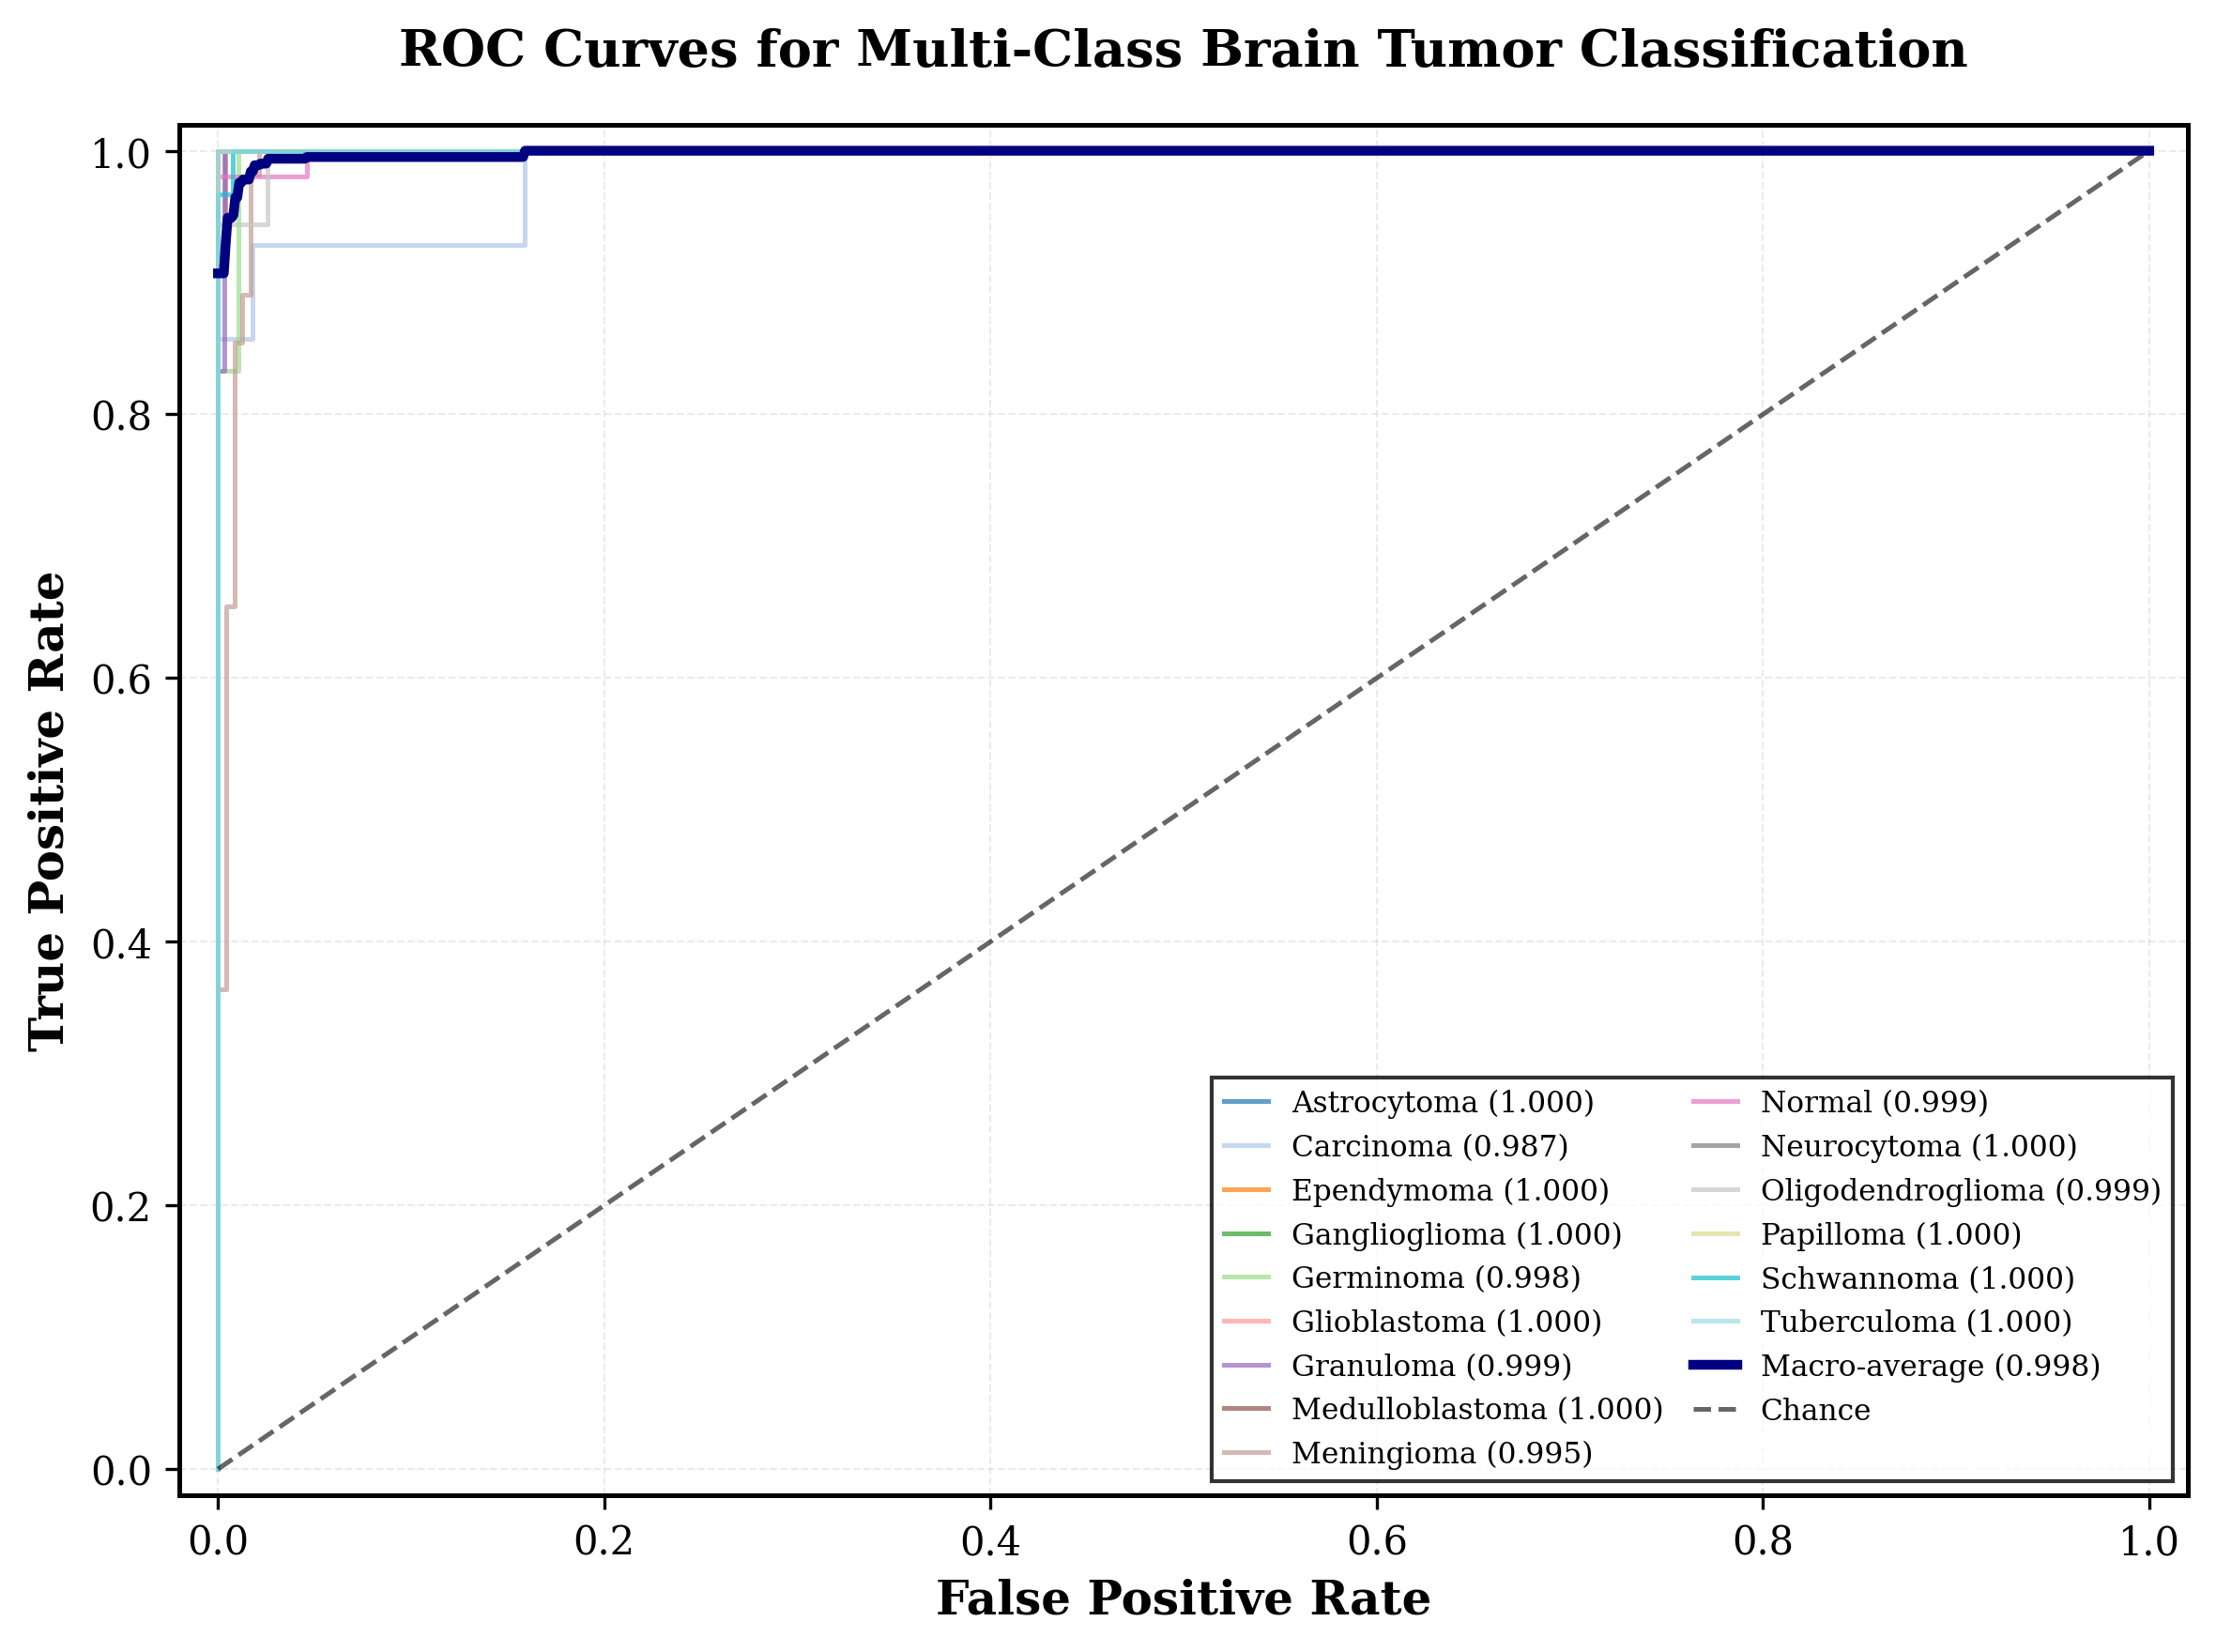

PUBLICATION-QUALITY ROC CURVES GENERATED
Macro-average AUC: 0.998433

Files saved:
  • roc_publication_quality.pdf (vector graphics)
  • roc_publication_quality.png (high-resolution)
  • roc_auc_per_class.csv (sorted by AUC)

Top 5 performing classes:
  1. Ependymoma: 1.0000
  2. Ganglioglioma: 1.0000
  3. Medulloblastoma: 1.0000
  4. Neurocytoma: 1.0000
  5. Papilloma: 1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from matplotlib import rcParams
from cycler import cycler

# ========== PUBLICATION-QUALITY SETTINGS ==========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 8.5
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'  # PDF for vector graphics
rcParams['pdf.fonttype'] = 42  # TrueType fonts (required by many journals)
rcParams['ps.fonttype'] = 42
rcParams['axes.linewidth'] = 1.2
rcParams['grid.linewidth'] = 0.5
rcParams['lines.linewidth'] = 1.5

# Load data
npz_path = r"/home/nirob/Desktop/Brain tumor mri /runs/T1/seed0/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed0_VAL_roc_pr_curves.npz"
data = np.load(npz_path, allow_pickle=True)

# Class labels
class_names = [
    'Astrocytoma', 'Carcinoma', 'Ependymoma', 'Ganglioglioma', 'Germinoma',
    'Glioblastoma', 'Granuloma', 'Medulloblastoma', 'Meningioma', 'Normal',
    'Neurocytoma', 'Oligodendroglioma', 'Papilloma', 'Schwannoma', 'Tuberculoma'
]
C = len(class_names)

# Safety check
for c in range(C):
    if f"fpr_{c}" not in data or f"tpr_{c}" not in data:
        raise KeyError(f"Missing ROC arrays for class {c}")

# ========== PROFESSIONAL COLOR SCHEME ==========
# Use a perceptually uniform colormap
colors = plt.cm.tab20(np.linspace(0, 1, C))

# ========== CREATE FIGURE ==========
fig, ax = plt.subplots(figsize=(8, 6))

auc_rows = []
fpr_grid = np.linspace(0.0, 1.0, 1001)
tpr_stack = []

# Plot individual class ROC curves
for c, name in enumerate(class_names):
    fpr = np.asarray(data[f"fpr_{c}"], dtype=np.float64)
    tpr = np.asarray(data[f"tpr_{c}"], dtype=np.float64)
    
    # Ensure monotonic FPR
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]
    
    # Calculate AUC
    auc = float(np.trapz(tpr, fpr))
    auc_rows.append((c, name, auc))
    
    # Plot with transparency for overlapping curves
    ax.plot(fpr, tpr, color=colors[c], linewidth=1.2, alpha=0.7, 
            label=f"{name} ({auc:.3f})")
    
    # Interpolate for macro-average
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_stack.append(tpr_interp)

# ========== MACRO-AVERAGE ROC ==========
tpr_macro = np.mean(np.stack(tpr_stack, axis=0), axis=0)
auc_macro = float(np.trapz(tpr_macro, fpr_grid))
ax.plot(fpr_grid, tpr_macro, color='navy', linewidth=2.5, 
        label=f"Macro-average ({auc_macro:.3f})", zorder=100)

# ========== CHANCE DIAGONAL ==========
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Chance')

# ========== FORMATTING ==========
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves for Multi-Class Brain Tumor Classification', 
             fontweight='bold', pad=15)

# Grid
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Limits
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Legend - two columns for better space utilization
ax.legend(loc='lower right', frameon=True, shadow=False, 
          fancybox=False, ncol=2, columnspacing=1.0,
          handlelength=1.5, fontsize=7.5, edgecolor='black')

# Tight layout
plt.tight_layout()

# ========== SAVE OUTPUTS ==========
# Save as PDF (vector) for publication
plt.savefig("roc_publication_quality.pdf", dpi=300, bbox_inches="tight")
# Also save as high-res PNG
plt.savefig("roc_publication_quality.png", dpi=300, bbox_inches="tight")
plt.show()

# ========== SAVE AUC TABLE ==========
auc_rows_sorted = sorted(auc_rows, key=lambda x: x[2], reverse=True)
with open("roc_auc_per_class.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Class Index", "Class Name", "AUC"])
    w.writerows(auc_rows_sorted)
    # Add macro-average at the end
    w.writerow(["—", "Macro-average", f"{auc_macro:.6f}"])

# ========== PRINT SUMMARY ==========
print("=" * 60)
print("PUBLICATION-QUALITY ROC CURVES GENERATED")
print("=" * 60)
print(f"Macro-average AUC: {auc_macro:.6f}")
print("\nFiles saved:")
print("  • roc_publication_quality.pdf (vector graphics)")
print("  • roc_publication_quality.png (high-resolution)")
print("  • roc_auc_per_class.csv (sorted by AUC)")
print("\nTop 5 performing classes:")
for i, (idx, name, auc) in enumerate(auc_rows_sorted[:5], 1):
    print(f"  {i}. {name}: {auc:.4f}")
print("=" * 60)

# zoomed and panned ROC Curve

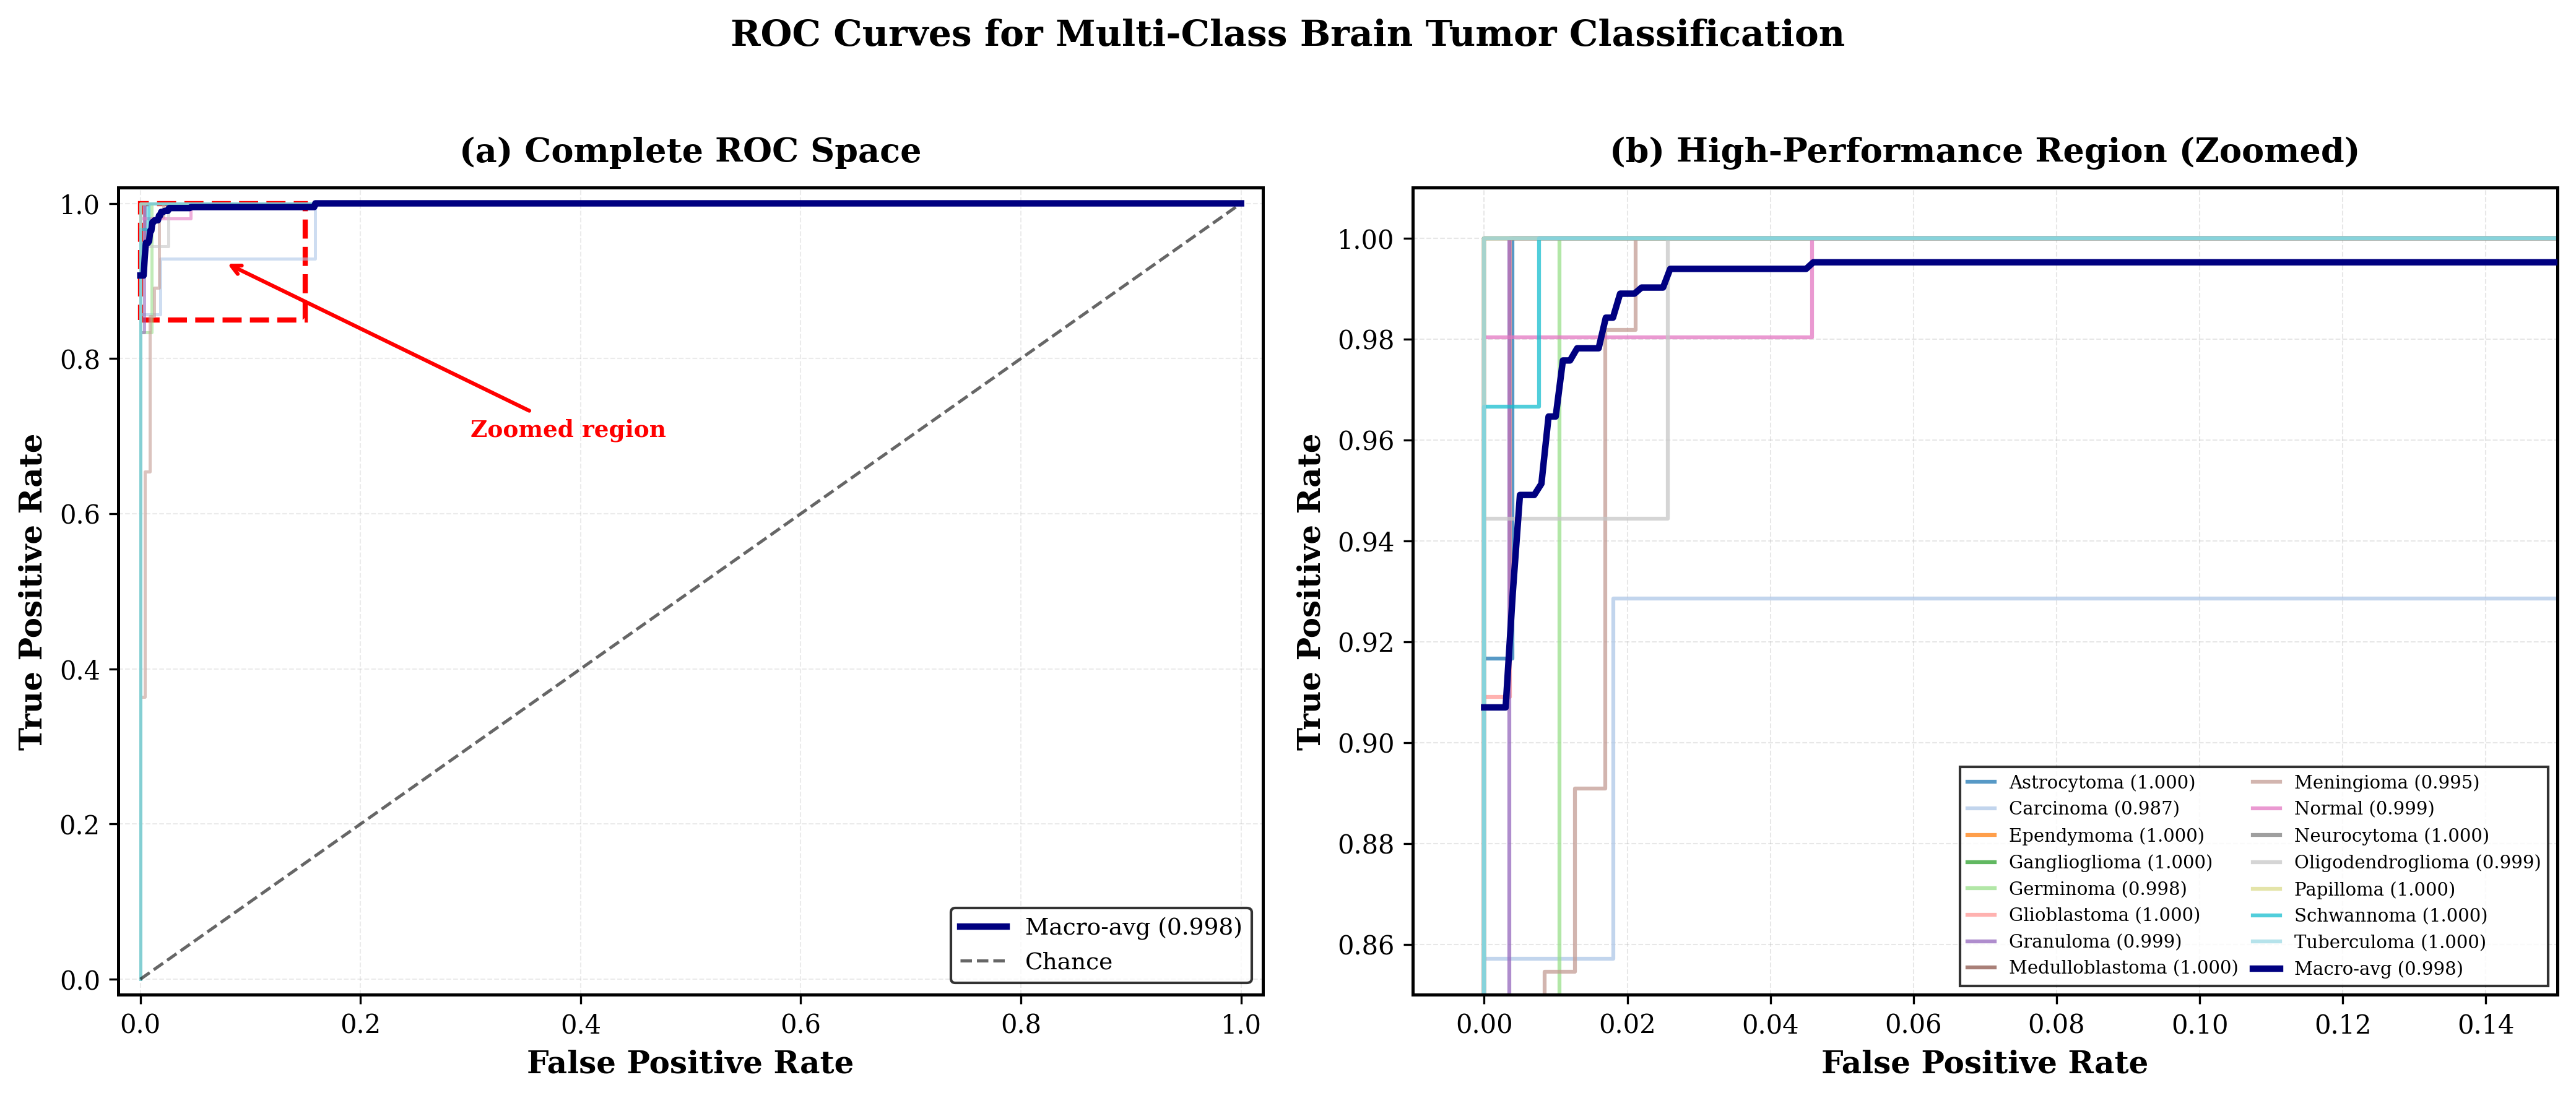

PUBLICATION-QUALITY ROC CURVES GENERATED
Macro-average AUC: 0.998433

Files saved:
  • roc_publication_zoomed.pdf (vector graphics)
  • roc_publication_zoomed.png (high-resolution)
  • roc_auc_per_class.csv (sorted by AUC)

AUC Performance Summary:
   1. Ependymoma           AUC: 1.0000
   2. Ganglioglioma        AUC: 1.0000
   3. Medulloblastoma      AUC: 1.0000
   4. Neurocytoma          AUC: 1.0000
   5. Papilloma            AUC: 1.0000
   6. Tuberculoma          AUC: 1.0000
   7. Schwannoma           AUC: 0.9997
   8. Glioblastoma         AUC: 0.9997
   9. Astrocytoma          AUC: 0.9997
  10. Granuloma            AUC: 0.9994
  11. Normal               AUC: 0.9991
  12. Oligodendroglioma    AUC: 0.9986
  13. Germinoma            AUC: 0.9982
  14. Meningioma           AUC: 0.9947
  15. Carcinoma            AUC: 0.9874

💡 TIP: Adjust zoom region in the code (ax2.set_xlim/ylim)
    to best showcase the differences between your classes.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from matplotlib import rcParams

# ========== PUBLICATION-QUALITY SETTINGS ==========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 8.5
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['axes.linewidth'] = 1.2
rcParams['grid.linewidth'] = 0.5
rcParams['lines.linewidth'] = 1.5

# Load data
npz_path = r"/home/nirob/Desktop/Brain tumor mri /runs/T1/seed0/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed0_VAL_roc_pr_curves.npz"
data = np.load(npz_path, allow_pickle=True)

# Class labels
class_names = [
    'Astrocytoma', 'Carcinoma', 'Ependymoma', 'Ganglioglioma', 'Germinoma',
    'Glioblastoma', 'Granuloma', 'Medulloblastoma', 'Meningioma', 'Normal',
    'Neurocytoma', 'Oligodendroglioma', 'Papilloma', 'Schwannoma', 'Tuberculoma'
]
C = len(class_names)

# Safety check
for c in range(C):
    if f"fpr_{c}" not in data or f"tpr_{c}" not in data:
        raise KeyError(f"Missing ROC arrays for class {c}")

# ========== PROFESSIONAL COLOR SCHEME ==========
colors = plt.cm.tab20(np.linspace(0, 1, C))

# ========== CREATE TWO-PANEL FIGURE ==========
fig = plt.figure(figsize=(14, 6))

# LEFT PANEL: Full ROC space (0 to 1)
ax1 = plt.subplot(1, 2, 1)
# RIGHT PANEL: Zoomed to high-performance region
ax2 = plt.subplot(1, 2, 2)

auc_rows = []
fpr_grid = np.linspace(0.0, 1.0, 1001)
tpr_stack = []

# Plot on both panels
for c, name in enumerate(class_names):
    fpr = np.asarray(data[f"fpr_{c}"], dtype=np.float64)
    tpr = np.asarray(data[f"tpr_{c}"], dtype=np.float64)
    
    # Ensure monotonic FPR
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]
    
    # Calculate AUC
    auc = float(np.trapz(tpr, fpr))
    auc_rows.append((c, name, auc))
    
    # Plot on full ROC (left panel) - no labels to reduce clutter
    ax1.plot(fpr, tpr, color=colors[c], linewidth=1.2, alpha=0.6)
    
    # Plot on zoomed ROC (right panel) - with labels
    ax2.plot(fpr, tpr, color=colors[c], linewidth=1.5, alpha=0.75, 
             label=f"{name} ({auc:.3f})")
    
    # Interpolate for macro-average
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_stack.append(tpr_interp)

# ========== MACRO-AVERAGE ROC ==========
tpr_macro = np.mean(np.stack(tpr_stack, axis=0), axis=0)
auc_macro = float(np.trapz(tpr_macro, fpr_grid))

# Plot macro-average on both panels
ax1.plot(fpr_grid, tpr_macro, color='navy', linewidth=2.5, 
         label=f"Macro-avg ({auc_macro:.3f})", zorder=100)
ax2.plot(fpr_grid, tpr_macro, color='navy', linewidth=2.5, 
         label=f"Macro-avg ({auc_macro:.3f})", zorder=100)

# ========== CHANCE DIAGONAL ==========
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Chance')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6)

# ========== LEFT PANEL FORMATTING ==========
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('(a) Complete ROC Space', fontweight='bold', pad=10)
ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax1.set_axisbelow(True)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.legend(loc='lower right', frameon=True, fontsize=9, edgecolor='black')

# ========== RIGHT PANEL FORMATTING (ZOOMED) ==========
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('(b) High-Performance Region (Zoomed)', fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)

# ZOOM to show differences (adjust these values based on your data)
ax2.set_xlim([-0.01, 0.15])  # Focus on low FPR region
ax2.set_ylim([0.85, 1.01])   # Focus on high TPR region

# Legend with two columns for the zoomed panel
ax2.legend(loc='lower right', frameon=True, shadow=False, 
          fancybox=False, ncol=2, columnspacing=0.8,
          handlelength=1.5, fontsize=7, edgecolor='black')

# Add a rectangle in left panel showing zoomed region
from matplotlib.patches import Rectangle
rect = Rectangle((0, 0.85), 0.15, 0.15, linewidth=2, 
                 edgecolor='red', facecolor='none', linestyle='--')
ax1.add_patch(rect)
ax1.annotate('Zoomed region', xy=(0.075, 0.925), xytext=(0.3, 0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=9, color='red', fontweight='bold')

# Overall title
fig.suptitle('ROC Curves for Multi-Class Brain Tumor Classification', 
             fontweight='bold', fontsize=14, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ========== SAVE OUTPUTS ==========
plt.savefig("roc_publication_zoomed.pdf", dpi=300, bbox_inches="tight")
plt.savefig("roc_publication_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()

# ========== SAVE AUC TABLE ==========
auc_rows_sorted = sorted(auc_rows, key=lambda x: x[2], reverse=True)
with open("roc_auc_per_class.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Class Index", "Class Name", "AUC"])
    w.writerows(auc_rows_sorted)
    w.writerow(["—", "Macro-average", f"{auc_macro:.6f}"])

# ========== PRINT SUMMARY ==========
print("=" * 60)
print("PUBLICATION-QUALITY ROC CURVES GENERATED")
print("=" * 60)
print(f"Macro-average AUC: {auc_macro:.6f}")
print("\nFiles saved:")
print("  • roc_publication_zoomed.pdf (vector graphics)")
print("  • roc_publication_zoomed.png (high-resolution)")
print("  • roc_auc_per_class.csv (sorted by AUC)")
print("\nAUC Performance Summary:")
for i, (idx, name, auc) in enumerate(auc_rows_sorted, 1):
    print(f"  {i:2d}. {name:20s} AUC: {auc:.4f}")
print("=" * 60)
print("\n💡 TIP: Adjust zoom region in the code (ax2.set_xlim/ylim)")
print("    to best showcase the differences between your classes.")
print("=" * 60)

# Zoomed ROC Curve

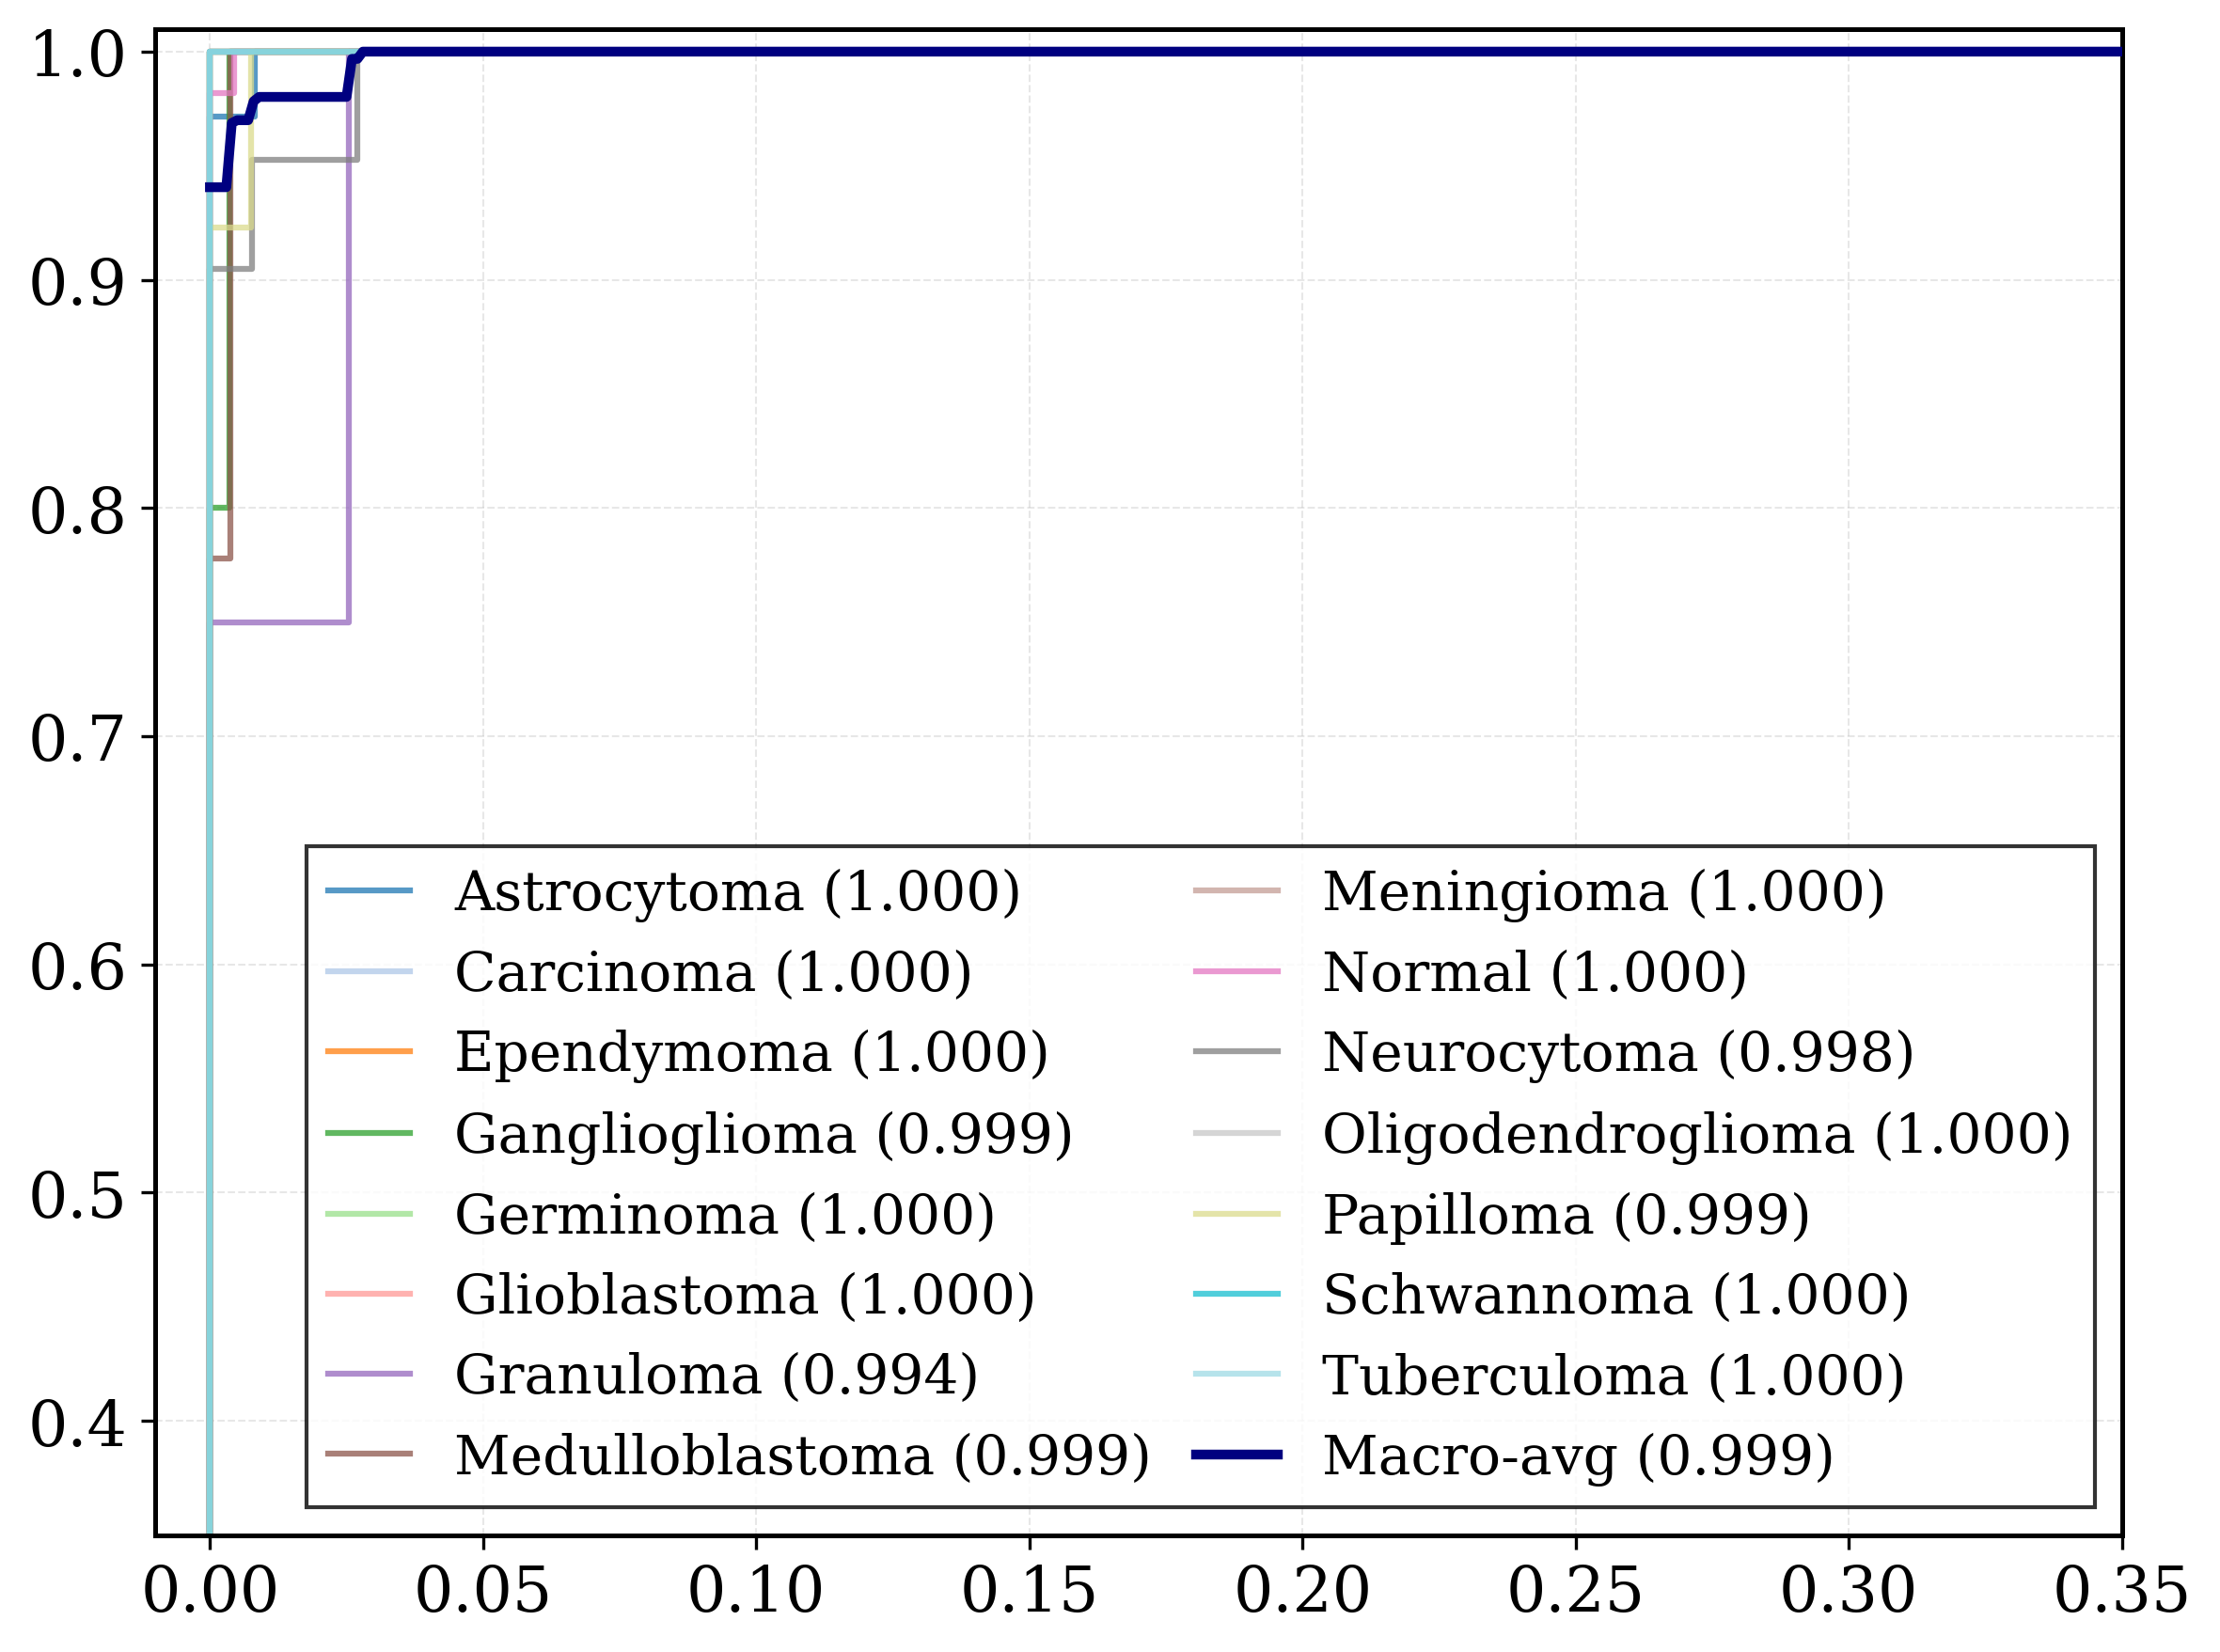

PUBLICATION-QUALITY ROC CURVES GENERATED
Macro-average AUC: 0.999305

Files saved:
  • roc_publication_zoomed.pdf (vector graphics)
  • roc_publication_zoomed.png (high-resolution)
  • roc_auc_per_class.csv (sorted by AUC)

AUC Performance Summary:
   1. Carcinoma            AUC: 1.0000
   2. Ependymoma           AUC: 1.0000
   3. Germinoma            AUC: 1.0000
   4. Glioblastoma         AUC: 1.0000
   5. Meningioma           AUC: 1.0000
   6. Oligodendroglioma    AUC: 1.0000
   7. Schwannoma           AUC: 1.0000
   8. Tuberculoma          AUC: 1.0000
   9. Normal               AUC: 0.9999
  10. Astrocytoma          AUC: 0.9998
  11. Papilloma            AUC: 0.9994
  12. Ganglioglioma        AUC: 0.9993
  13. Medulloblastoma      AUC: 0.9992
  14. Neurocytoma          AUC: 0.9983
  15. Granuloma            AUC: 0.9937

💡 TIP: Adjust zoom region in the code (ax.set_xlim/ylim)
    Current: FPR [0, 0.15], TPR [0.85, 1.0]


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from matplotlib import rcParams

# ========== PUBLICATION-QUALITY SETTINGS ==========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16
rcParams['legend.fontsize'] = 8.5
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['axes.linewidth'] = 1.2
rcParams['grid.linewidth'] = 0.5
rcParams['lines.linewidth'] = 1.5

# Load data
npz_path = r"/home/nirob/Desktop/Brain tumor mri /diff_models/EfficientNet-B0/T2/seed0/STNROI+efficientnet_b0.ra4_e3600_r224_in1k_seed0_VAL_roc_pr_curves.npz"
data = np.load(npz_path, allow_pickle=True)

# Class labels
class_names = [
    'Astrocytoma', 'Carcinoma', 'Ependymoma', 'Ganglioglioma', 'Germinoma',
    'Glioblastoma', 'Granuloma', 'Medulloblastoma', 'Meningioma', 'Normal',
    'Neurocytoma', 'Oligodendroglioma', 'Papilloma', 'Schwannoma', 'Tuberculoma'
]
C = len(class_names)

# Safety check
for c in range(C):
    if f"fpr_{c}" not in data or f"tpr_{c}" not in data:
        raise KeyError(f"Missing ROC arrays for class {c}")

# ========== PROFESSIONAL COLOR SCHEME ==========
colors = plt.cm.tab20(np.linspace(0, 1, C))

# ========== CREATE SINGLE ZOOMED FIGURE ==========
fig, ax = plt.subplots(figsize=(8, 6))

auc_rows = []
fpr_grid = np.linspace(0.0, 1.0, 1001)
tpr_stack = []

# Plot individual class ROC curves
for c, name in enumerate(class_names):
    fpr = np.asarray(data[f"fpr_{c}"], dtype=np.float64)
    tpr = np.asarray(data[f"tpr_{c}"], dtype=np.float64)
    
    # Ensure monotonic FPR
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]
    
    # Calculate AUC
    auc = float(np.trapz(tpr, fpr))
    auc_rows.append((c, name, auc))
    
    # Plot with labels
    ax.plot(fpr, tpr, color=colors[c], linewidth=1.5, alpha=0.75, 
            label=f"{name} ({auc:.3f})")
    
    # Interpolate for macro-average
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_stack.append(tpr_interp)

# ========== MACRO-AVERAGE ROC ==========
tpr_macro = np.mean(np.stack(tpr_stack, axis=0), axis=0)
auc_macro = float(np.trapz(tpr_macro, fpr_grid))
ax.plot(fpr_grid, tpr_macro, color='navy', linewidth=2.5, 
        label=f"Macro-avg ({auc_macro:.3f})", zorder=100)

# ========== CHANCE DIAGONAL ==========
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6)

# ========== FORMATTING ==========
# ax.set_xlabel('False Positive Rate', fontweight='bold')
# ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# ZOOM to show differences (adjust these values based on your data)
ax.set_xlim([-0.01, 0.35])  # Focus on low FPR region
ax.set_ylim([0.35, 1.01])   # Focus on high TPR region

# Legend with two columns
ax.legend(loc='lower right', frameon=True, shadow=False, 
          fancybox=False, ncol=2, columnspacing=0.8,
          handlelength=1.5, fontsize=14, edgecolor='black')

plt.tight_layout()

# ========== SAVE OUTPUTS ==========
plt.savefig("roc_publication_zoomed.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("roc_publication_zoomed.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# ========== SAVE AUC TABLE ==========
auc_rows_sorted = sorted(auc_rows, key=lambda x: x[2], reverse=True)
with open("roc_auc_per_class.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Class Index", "Class Name", "AUC"])
    w.writerows(auc_rows_sorted)
    w.writerow(["—", "Macro-average", f"{auc_macro:.6f}"])

# ========== PRINT SUMMARY ==========
print("=" * 60)
print("PUBLICATION-QUALITY ROC CURVES GENERATED")
print("=" * 60)
print(f"Macro-average AUC: {auc_macro:.6f}")
print("\nFiles saved:")
print("  • roc_publication_zoomed.pdf (vector graphics)")
print("  • roc_publication_zoomed.png (high-resolution)")
print("  • roc_auc_per_class.csv (sorted by AUC)")
print("\nAUC Performance Summary:")
for i, (idx, name, auc) in enumerate(auc_rows_sorted, 1):
    print(f"  {i:2d}. {name:20s} AUC: {auc:.4f}")
print("=" * 60)
print("\n💡 TIP: Adjust zoom region in the code (ax.set_xlim/ylim)")
print("    Current: FPR [0, 0.15], TPR [0.85, 1.0]")
print("=" * 60)

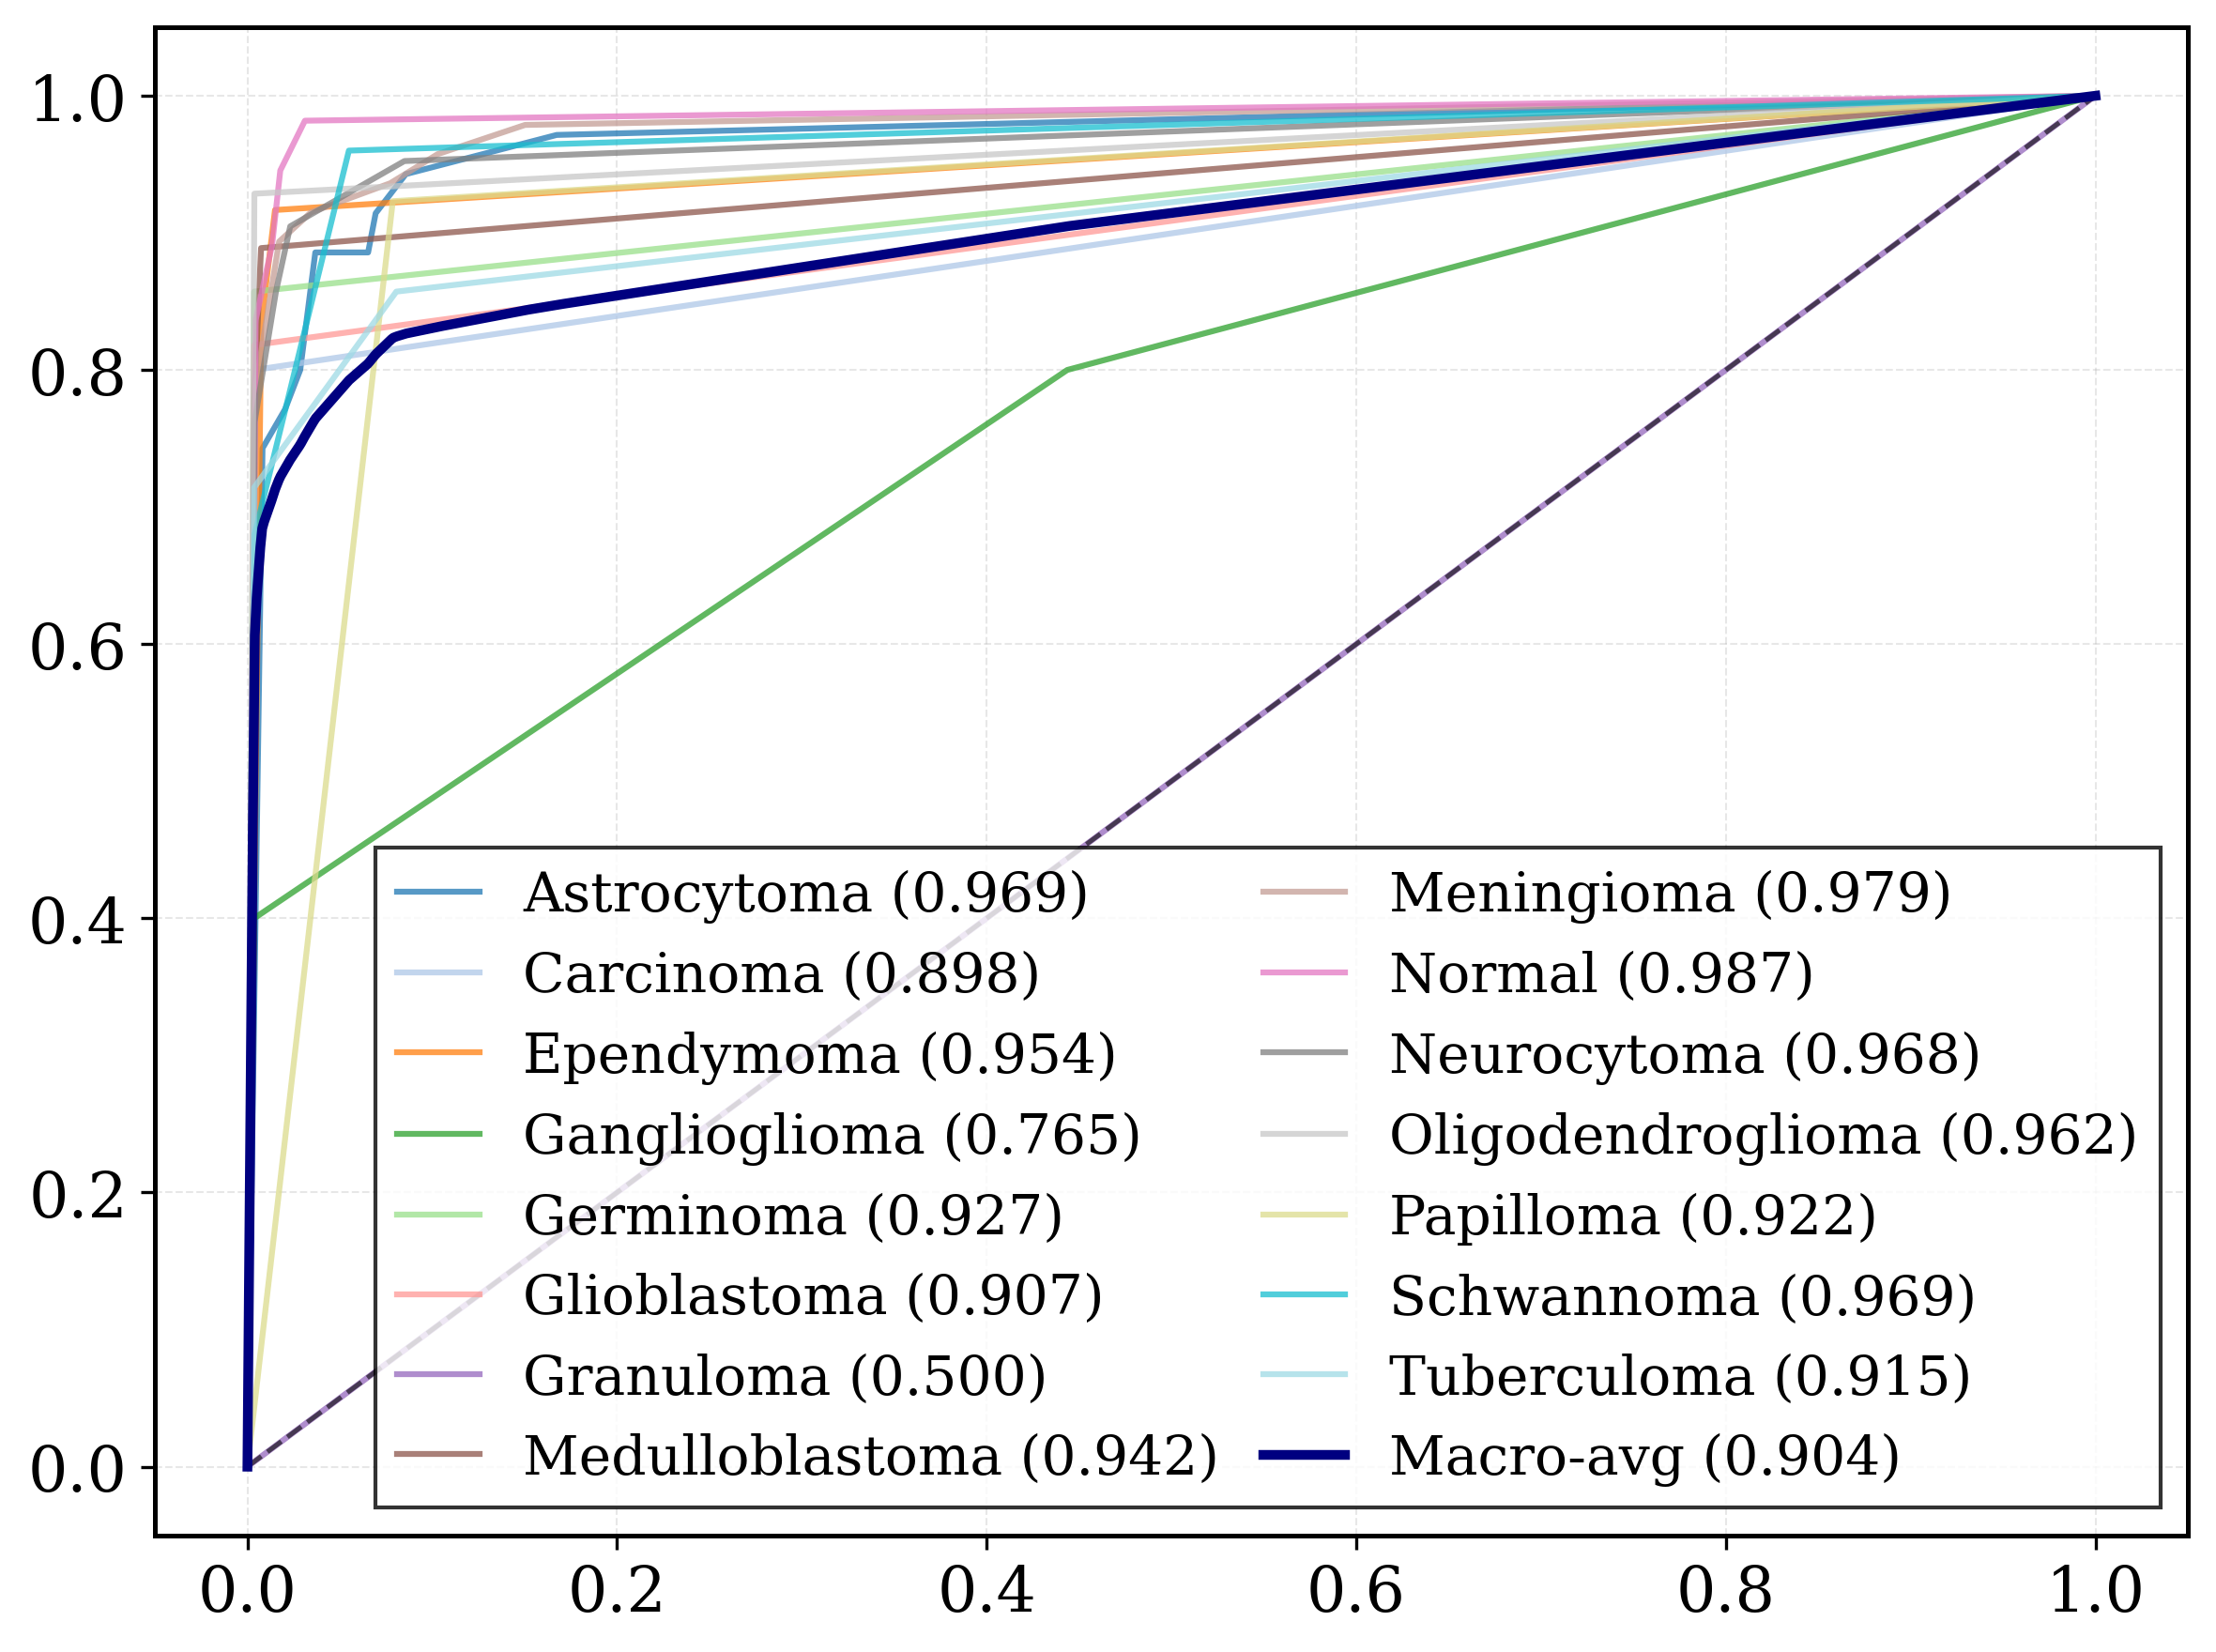

PUBLICATION-QUALITY ROC CURVES GENERATED
Macro-average AUC: 0.904297

Files saved:
  • roc_publication_zoomed.pdf (vector graphics)
  • roc_publication_zoomed.png (high-resolution)
  • roc_auc_per_class.csv (sorted by AUC)

AUC Performance Summary:
   1. Normal               AUC: 0.9865
   2. Meningioma           AUC: 0.9786
   3. Schwannoma           AUC: 0.9693
   4. Astrocytoma          AUC: 0.9686
   5. Neurocytoma          AUC: 0.9683
   6. Oligodendroglioma    AUC: 0.9624
   7. Ependymoma           AUC: 0.9537
   8. Medulloblastoma      AUC: 0.9420
   9. Germinoma            AUC: 0.9267
  10. Papilloma            AUC: 0.9222
  11. Tuberculoma          AUC: 0.9155
  12. Glioblastoma         AUC: 0.9072
  13. Carcinoma            AUC: 0.8981
  14. Ganglioglioma        AUC: 0.7655
  15. Granuloma            AUC: 0.5000
💡 TIP: Adjust zoom with ax.set_xlim / ax.set_ylim
    Current: FPR [-0.05, 1.05], TPR [-0.05, 1.05]


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from matplotlib import rcParams

# ========== PUBLICATION-QUALITY SETTINGS ==========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16
rcParams['legend.fontsize'] = 8.5
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['axes.linewidth'] = 1.2
rcParams['grid.linewidth'] = 0.5
rcParams['lines.linewidth'] = 1.5

# =========================
# PATH (edit as needed)
# =========================
npz_path = r"/home/nirob/Desktop/Brain tumor mri /benchmark_outputs_timm_q1/T2/DenseNet-121/seed_0/DenseNet-121_seed0_VAL_roc_pr_curves.npz"
data = np.load(npz_path, allow_pickle=True)

# =========================
# CLASS NAMES (paper-friendly)
# =========================
class_names = [
    'Astrocytoma', 'Carcinoma', 'Ependymoma', 'Ganglioglioma', 'Germinoma',
    'Glioblastoma', 'Granuloma', 'Medulloblastoma', 'Meningioma', 'Normal',
    'Neurocytoma', 'Oligodendroglioma', 'Papilloma', 'Schwannoma', 'Tuberculoma'
]
# Optional: use names saved in the npz (uncomment if you prefer)
# if "class_names" in data.files:
#     class_names = list(data["class_names"])

C = len(class_names)

# =========================
# KEY DETECTION (FIX)
# =========================
if "roc_fpr_0" in data.files and "roc_tpr_0" in data.files:
    fpr_key = lambda c: f"roc_fpr_{c}"
    tpr_key = lambda c: f"roc_tpr_{c}"
elif "fpr_0" in data.files and "tpr_0" in data.files:
    fpr_key = lambda c: f"fpr_{c}"
    tpr_key = lambda c: f"tpr_{c}"
else:
    raise KeyError(
        "Could not find ROC keys in NPZ. Available keys:\n"
        + "\n".join(data.files)
    )

# Safety check
for c in range(C):
    if fpr_key(c) not in data.files or tpr_key(c) not in data.files:
        raise KeyError(f"Missing ROC arrays for class {c}: {fpr_key(c)} / {tpr_key(c)}")

# =========================
# HELPERS
# =========================
def sort_and_clean_roc(fpr, tpr):
    fpr = np.asarray(fpr, dtype=np.float64).reshape(-1)
    tpr = np.asarray(tpr, dtype=np.float64).reshape(-1)

    # drop non-finite
    m = np.isfinite(fpr) & np.isfinite(tpr)
    fpr, tpr = fpr[m], tpr[m]

    # sort by fpr
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]

    # remove duplicate fpr (np.interp prefers strictly non-decreasing)
    if fpr.size > 1:
        fpr_u, idx = np.unique(fpr, return_index=True)
        tpr_u = tpr[idx]
        fpr, tpr = fpr_u, tpr_u

    # clamp to [0,1]
    fpr = np.clip(fpr, 0.0, 1.0)
    tpr = np.clip(tpr, 0.0, 1.0)

    # ensure endpoints for stable trapz/interp
    if fpr.size == 0:
        return fpr, tpr
    if fpr[0] > 0.0:
        fpr = np.insert(fpr, 0, 0.0)
        tpr = np.insert(tpr, 0, 0.0)
    if fpr[-1] < 1.0:
        fpr = np.append(fpr, 1.0)
        tpr = np.append(tpr, 1.0)

    return fpr, tpr

# =========================
# PLOT
# =========================
colors = plt.cm.tab20(np.linspace(0, 1, C))
fig, ax = plt.subplots(figsize=(8, 6))

auc_rows = []
fpr_grid = np.linspace(0.0, 1.0, 1001)
tpr_stack = []

for c, name in enumerate(class_names):
    fpr_raw = data[fpr_key(c)]
    tpr_raw = data[tpr_key(c)]
    fpr, tpr = sort_and_clean_roc(fpr_raw, tpr_raw)

    if fpr.size < 2:
        raise ValueError(f"Class {c} ({name}) ROC has too few points.")

    auc = float(np.trapz(tpr, fpr))
    auc_rows.append((c, name, auc))

    ax.plot(
        fpr, tpr,
        color=colors[c],
        linewidth=1.5,
        alpha=0.75,
        label=f"{name} ({auc:.3f})"
    )

    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_stack.append(tpr_interp)

# Macro-average ROC
tpr_macro = np.mean(np.stack(tpr_stack, axis=0), axis=0)
auc_macro = float(np.trapz(tpr_macro, fpr_grid))
ax.plot(
    fpr_grid, tpr_macro,
    color='navy',
    linewidth=2.5,
    label=f"Macro-avg ({auc_macro:.3f})",
    zorder=100
)

# Chance diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6)

# Formatting
# ax.set_xlabel('False Positive Rate', fontweight='bold')
# ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# # ZOOM (edit these)
# ax.set_xlim([-0.01, 0.35])
# ax.set_ylim([0.01, 1.01])

ax.legend(
    loc='lower right',
    frameon=True,
    shadow=False,
    fancybox=False,
    ncol=2,
    columnspacing=0.8,
    handlelength=1.5,
    fontsize=14,
    edgecolor='black'
)

plt.tight_layout()

# Save
plt.savefig("roc_publication_zoomed.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("roc_publication_zoomed.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# =========================
# SAVE AUC TABLE
# =========================
auc_rows_sorted = sorted(auc_rows, key=lambda x: x[2], reverse=True)
with open("roc_auc_per_class.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Class Index", "Class Name", "AUC"])
    w.writerows(auc_rows_sorted)
    w.writerow(["—", "Macro-average", f"{auc_macro:.6f}"])

# =========================
# PRINT SUMMARY
# =========================
print("=" * 60)
print("PUBLICATION-QUALITY ROC CURVES GENERATED")
print("=" * 60)
print(f"Macro-average AUC: {auc_macro:.6f}")
print("\nFiles saved:")
print("  • roc_publication_zoomed.pdf (vector graphics)")
print("  • roc_publication_zoomed.png (high-resolution)")
print("  • roc_auc_per_class.csv (sorted by AUC)")
print("\nAUC Performance Summary:")
for i, (idx, name, auc) in enumerate(auc_rows_sorted, 1):
    print(f"  {i:2d}. {name:20s} AUC: {auc:.4f}")
print("=" * 60)
print("💡 TIP: Adjust zoom with ax.set_xlim / ax.set_ylim")
print(f"    Current: FPR [{ax.get_xlim()[0]:.2f}, {ax.get_xlim()[1]:.2f}], "
      f"TPR [{ax.get_ylim()[0]:.2f}, {ax.get_ylim()[1]:.2f}]")
print("=" * 60)


# Confusion matrix

Classes found in CSV (14): ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13']


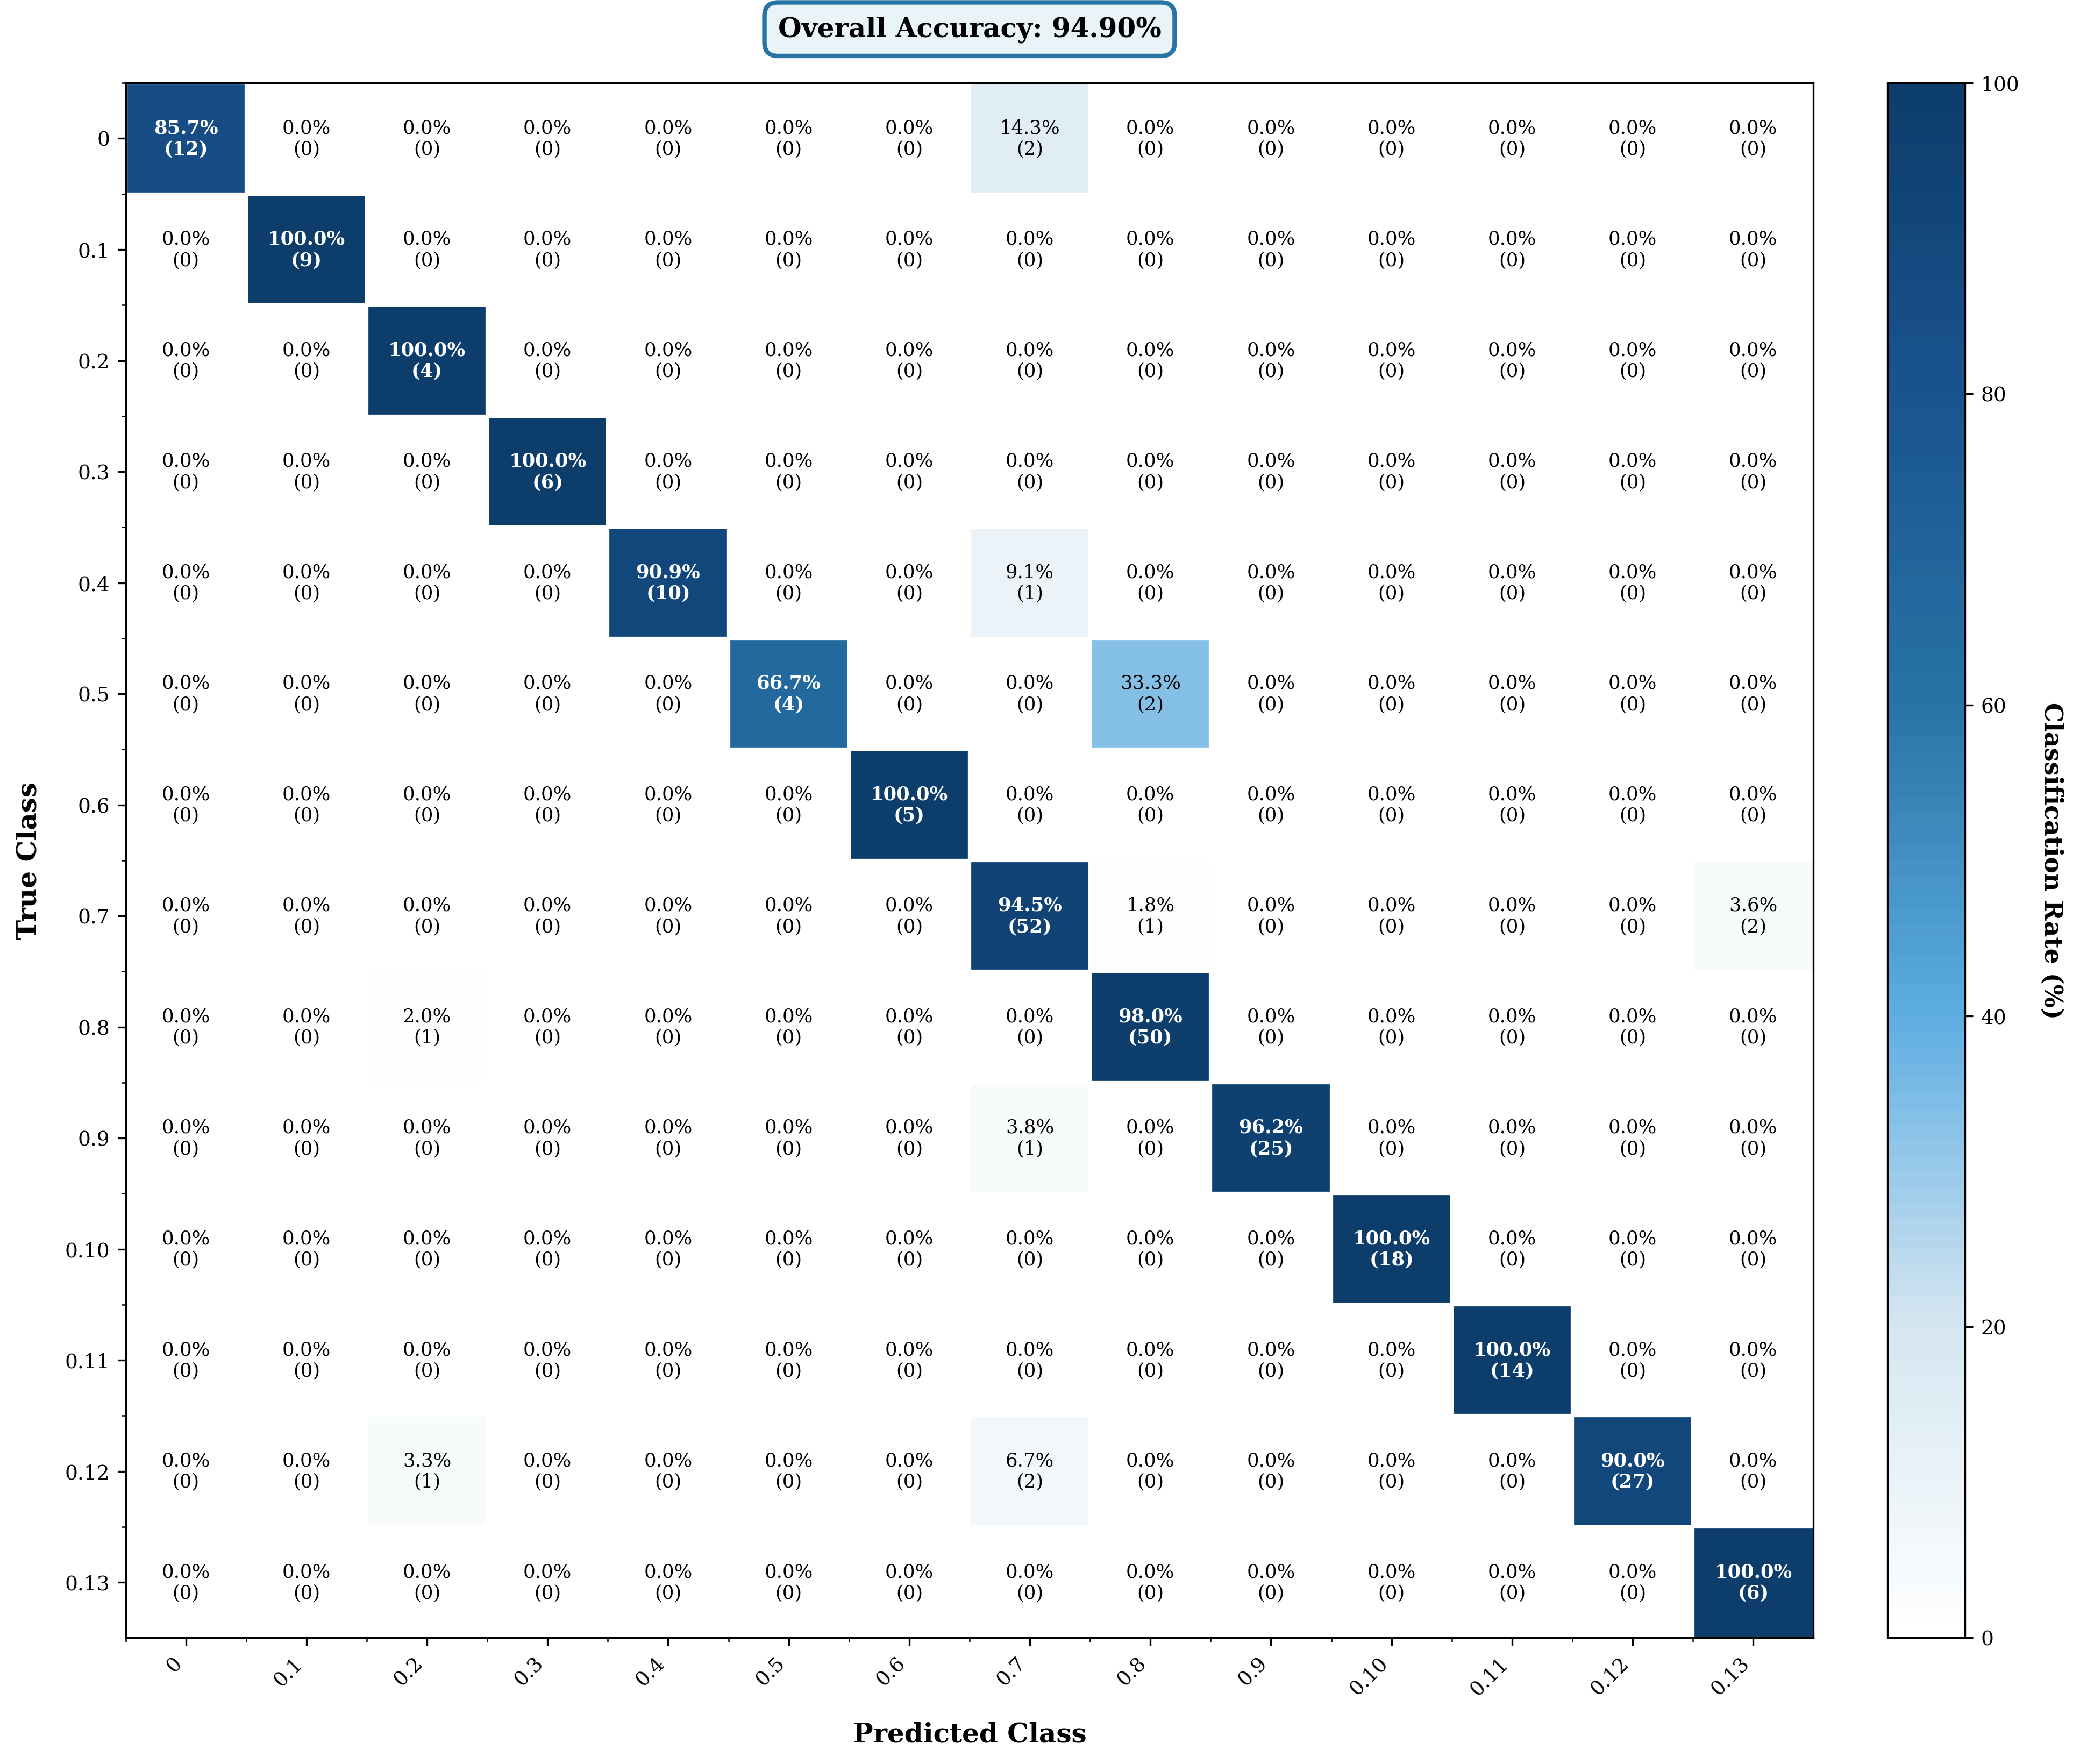

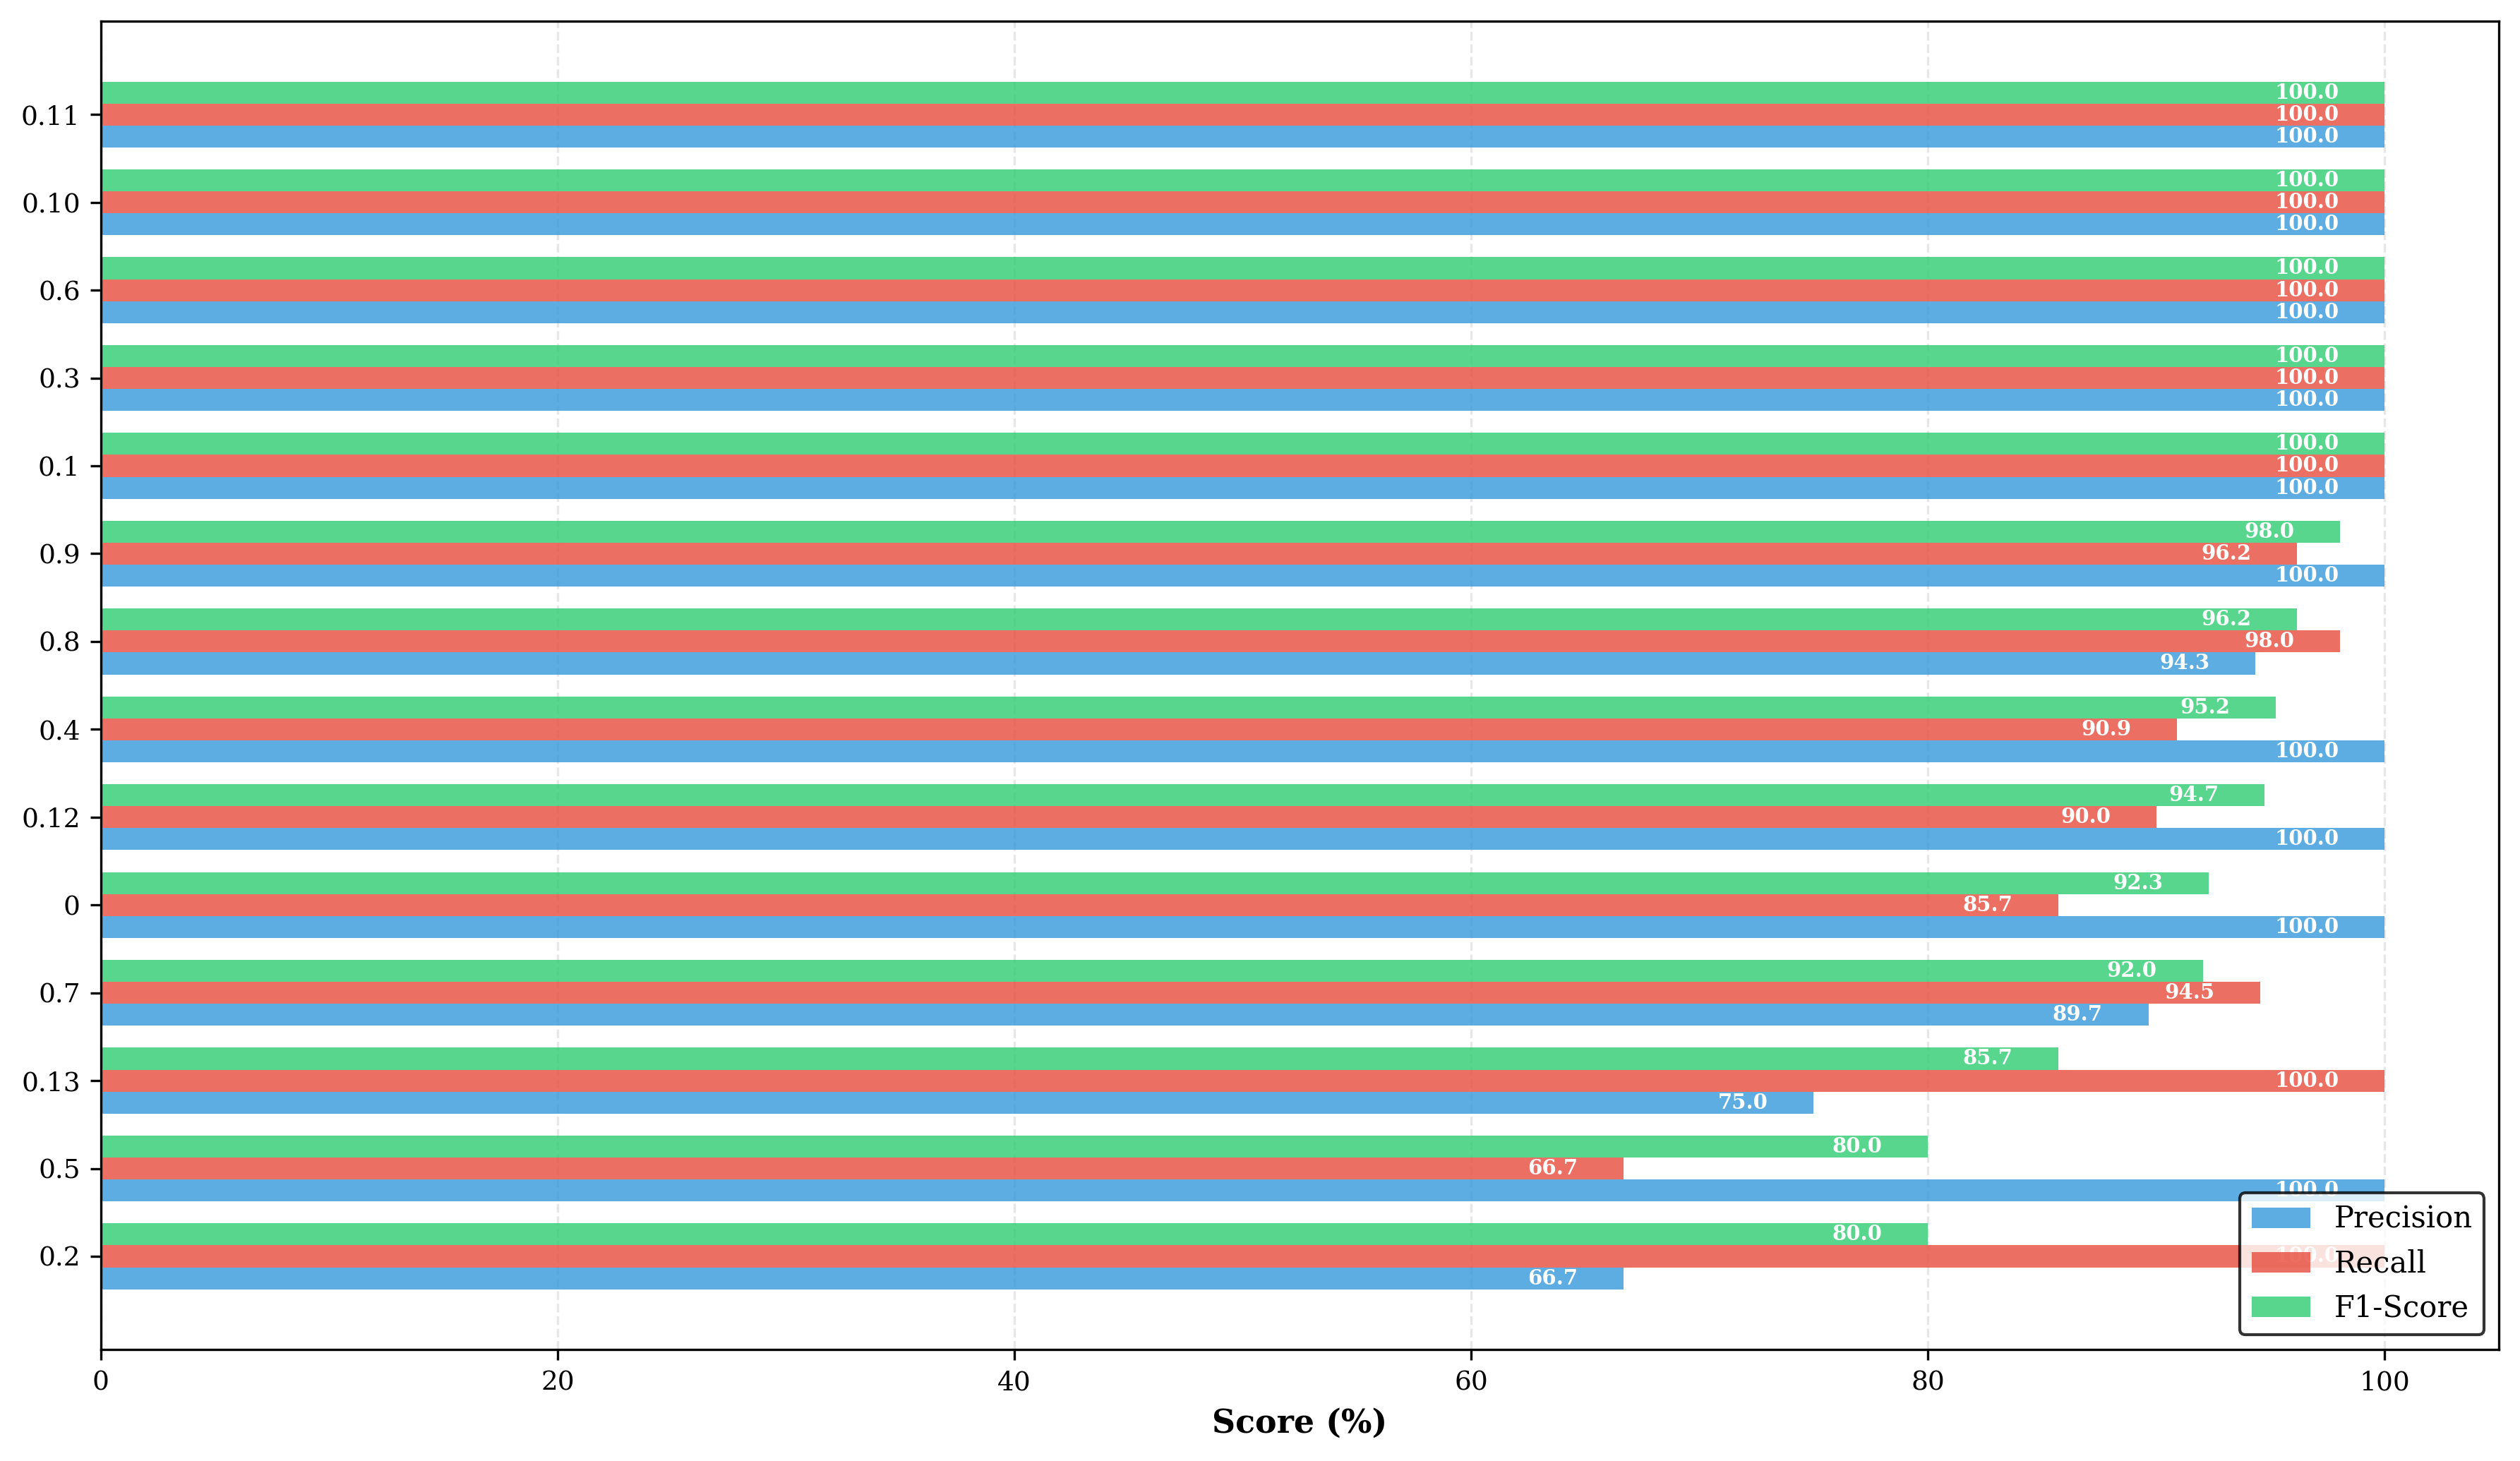

PUBLICATION-QUALITY CONFUSION MATRIX & METRICS GENERATED
Overall Accuracy: 94.90%
Number of Classes: 14
Total Samples: 255

Files saved:
  • confusion_matrix_publication.pdf/png (vibrant colors)
  • classification_metrics_bars.pdf/png (per-class performance)
  • classification_metrics_per_class.csv

Top 5 Performing Classes (by F1-Score):
  0.1                  - F1: 100.00%, Precision: 100.00%, Recall: 100.00%
  0.3                  - F1: 100.00%, Precision: 100.00%, Recall: 100.00%
  0.6                  - F1: 100.00%, Precision: 100.00%, Recall: 100.00%
  0.10                 - F1: 100.00%, Precision: 100.00%, Recall: 100.00%
  0.11                 - F1: 100.00%, Precision: 100.00%, Recall: 100.00%


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

# ========== PUBLICATION-QUALITY SETTINGS ==========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

# Load confusion matrix
csv_path = r"/home/nirob/Desktop/Brain tumor mri /runs/Proposed Model/T1/seed24/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed24_VAL_confusion_matrix.csv"
df = pd.read_csv(csv_path, index_col=0)

# Extract confusion matrix values
cm = df.values

# Check actual number of classes in the CSV
actual_classes = df.columns.tolist()
print(f"Classes found in CSV ({len(actual_classes)}): {actual_classes}")

# Define class names - use only the ones present in your data
# Adjust this list based on which 14 classes you actually have
class_names_full = [
    'Astrocytoma', 'Carcinoma', 'Ependymoma', 'Ganglioglioma', 'Germinoma',
    'Glioblastoma', 'Granuloma', 'Medulloblastoma', 'Meningioma', 'Normal',
    'Neurocytoma', 'Oligodendroglioma', 'Papilloma', 'Schwannoma', 'Tuberculoma'
]

# Use actual class names from CSV (will be corrected after we see what's in the file)
class_names = actual_classes if len(actual_classes) == len(cm) else class_names_full[:len(cm)]

# Calculate normalized confusion matrix (row-wise percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# ========== CREATE CUSTOM COLORMAP ==========
# Vibrant gradient: white -> light blue -> deep blue -> navy
colors_list = ['#ffffff', '#d4e6f1', '#5dade2', '#2874a6', '#1a5490', '#0d3d6b']
n_bins = 100
cmap_custom = LinearSegmentedColormap.from_list('custom_blues', colors_list, N=n_bins)

# ========== CREATE MAIN FIGURE (NORMALIZED) ==========
fig, ax = plt.subplots(figsize=(13, 11))

# Create mask for diagonal (perfect predictions)
mask_diagonal = np.eye(len(class_names), dtype=bool)

# Plot heatmap
im = ax.imshow(cm_normalized, cmap=cmap_custom, aspect='auto', vmin=0, vmax=100)

# Add colorbar with better styling
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Classification Rate (%)', rotation=270, labelpad=20, 
               fontweight='bold', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# Add text annotations with dynamic coloring
for i in range(len(class_names)):
    for j in range(len(class_names)):
        value = cm_normalized[i, j]
        count = cm[i, j]
        
        # Choose text color based on background intensity
        text_color = 'white' if value > 50 else 'black'
        
        # Bold diagonal elements
        weight = 'bold' if i == j else 'normal'
        
        # Show percentage with count in smaller font
        text = f'{value:.1f}%\n({int(count)})'
        ax.text(j, i, text, ha='center', va='center', 
               color=text_color, fontsize=8.5, weight=weight)

# Add grid lines
ax.set_xticks(np.arange(len(class_names)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(class_names)) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.5)

# Set labels
ax.set_xlabel('Predicted Class', fontweight='bold', fontsize=12, labelpad=10)
ax.set_ylabel('True Class', fontweight='bold', fontsize=12, labelpad=10)

# Set tick labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(class_names, rotation=0, fontsize=9)

# Calculate and display overall accuracy with styling
accuracy = np.trace(cm) / np.sum(cm) * 100
ax.text(0.5, 1.03, f'Overall Accuracy: {accuracy:.2f}%', 
        transform=ax.transAxes, ha='center', fontsize=12, 
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', 
                                      facecolor='#e8f4f8', 
                                      edgecolor='#2874a6', linewidth=2))

plt.tight_layout()

# Save
plt.savefig("confusion_matrix_publication.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("confusion_matrix_publication.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# ========== CALCULATE AND SAVE METRICS ==========
metrics = []
for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics.append({
        'Class': class_name,
        'Precision': precision * 100,
        'Recall': recall * 100,
        'F1-Score': f1 * 100,
        'Support': int(cm[i, :].sum())
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("classification_metrics_per_class.csv", index=False, float_format='%.2f')

# ========== CREATE METRICS VISUALIZATION ==========
fig2, ax2 = plt.subplots(figsize=(12, 7))

# Sort by F1-Score
metrics_sorted = metrics_df.sort_values('F1-Score', ascending=True)

# Create horizontal bar chart
y_pos = np.arange(len(metrics_sorted))
bars1 = ax2.barh(y_pos - 0.25, metrics_sorted['Precision'], 0.25, 
                 label='Precision', color='#3498db', alpha=0.8)
bars2 = ax2.barh(y_pos, metrics_sorted['Recall'], 0.25, 
                 label='Recall', color='#e74c3c', alpha=0.8)
bars3 = ax2.barh(y_pos + 0.25, metrics_sorted['F1-Score'], 0.25, 
                 label='F1-Score', color='#2ecc71', alpha=0.8)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(metrics_sorted['Class'])
ax2.set_xlabel('Score (%)', fontweight='bold', fontsize=11)
ax2.set_xlim([0, 105])
ax2.legend(loc='lower right', frameon=True, edgecolor='black', fontsize=10)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        width = bar.get_width()
        if width > 5:  # Only show if bar is visible
            ax2.text(width - 2, bar.get_y() + bar.get_height()/2, 
                    f'{width:.1f}', ha='right', va='center', 
                    color='white', fontweight='bold', fontsize=7)

plt.tight_layout()
plt.savefig("classification_metrics_bars.pdf", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("classification_metrics_bars.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# ========== PRINT SUMMARY ==========
print("=" * 70)
print("PUBLICATION-QUALITY CONFUSION MATRIX & METRICS GENERATED")
print("=" * 70)
print(f"Overall Accuracy: {accuracy:.2f}%")
print(f"Number of Classes: {len(class_names)}")
print(f"Total Samples: {int(cm.sum())}")
print("\nFiles saved:")
print("  • confusion_matrix_publication.pdf/png (vibrant colors)")
print("  • classification_metrics_bars.pdf/png (per-class performance)")
print("  • classification_metrics_per_class.csv")
print("\nTop 5 Performing Classes (by F1-Score):")
top5 = metrics_df.nlargest(5, 'F1-Score')
for idx, row in top5.iterrows():
    print(f"  {row['Class']:20s} - F1: {row['F1-Score']:.2f}%, "
          f"Precision: {row['Precision']:.2f}%, Recall: {row['Recall']:.2f}%")
print("=" * 70)

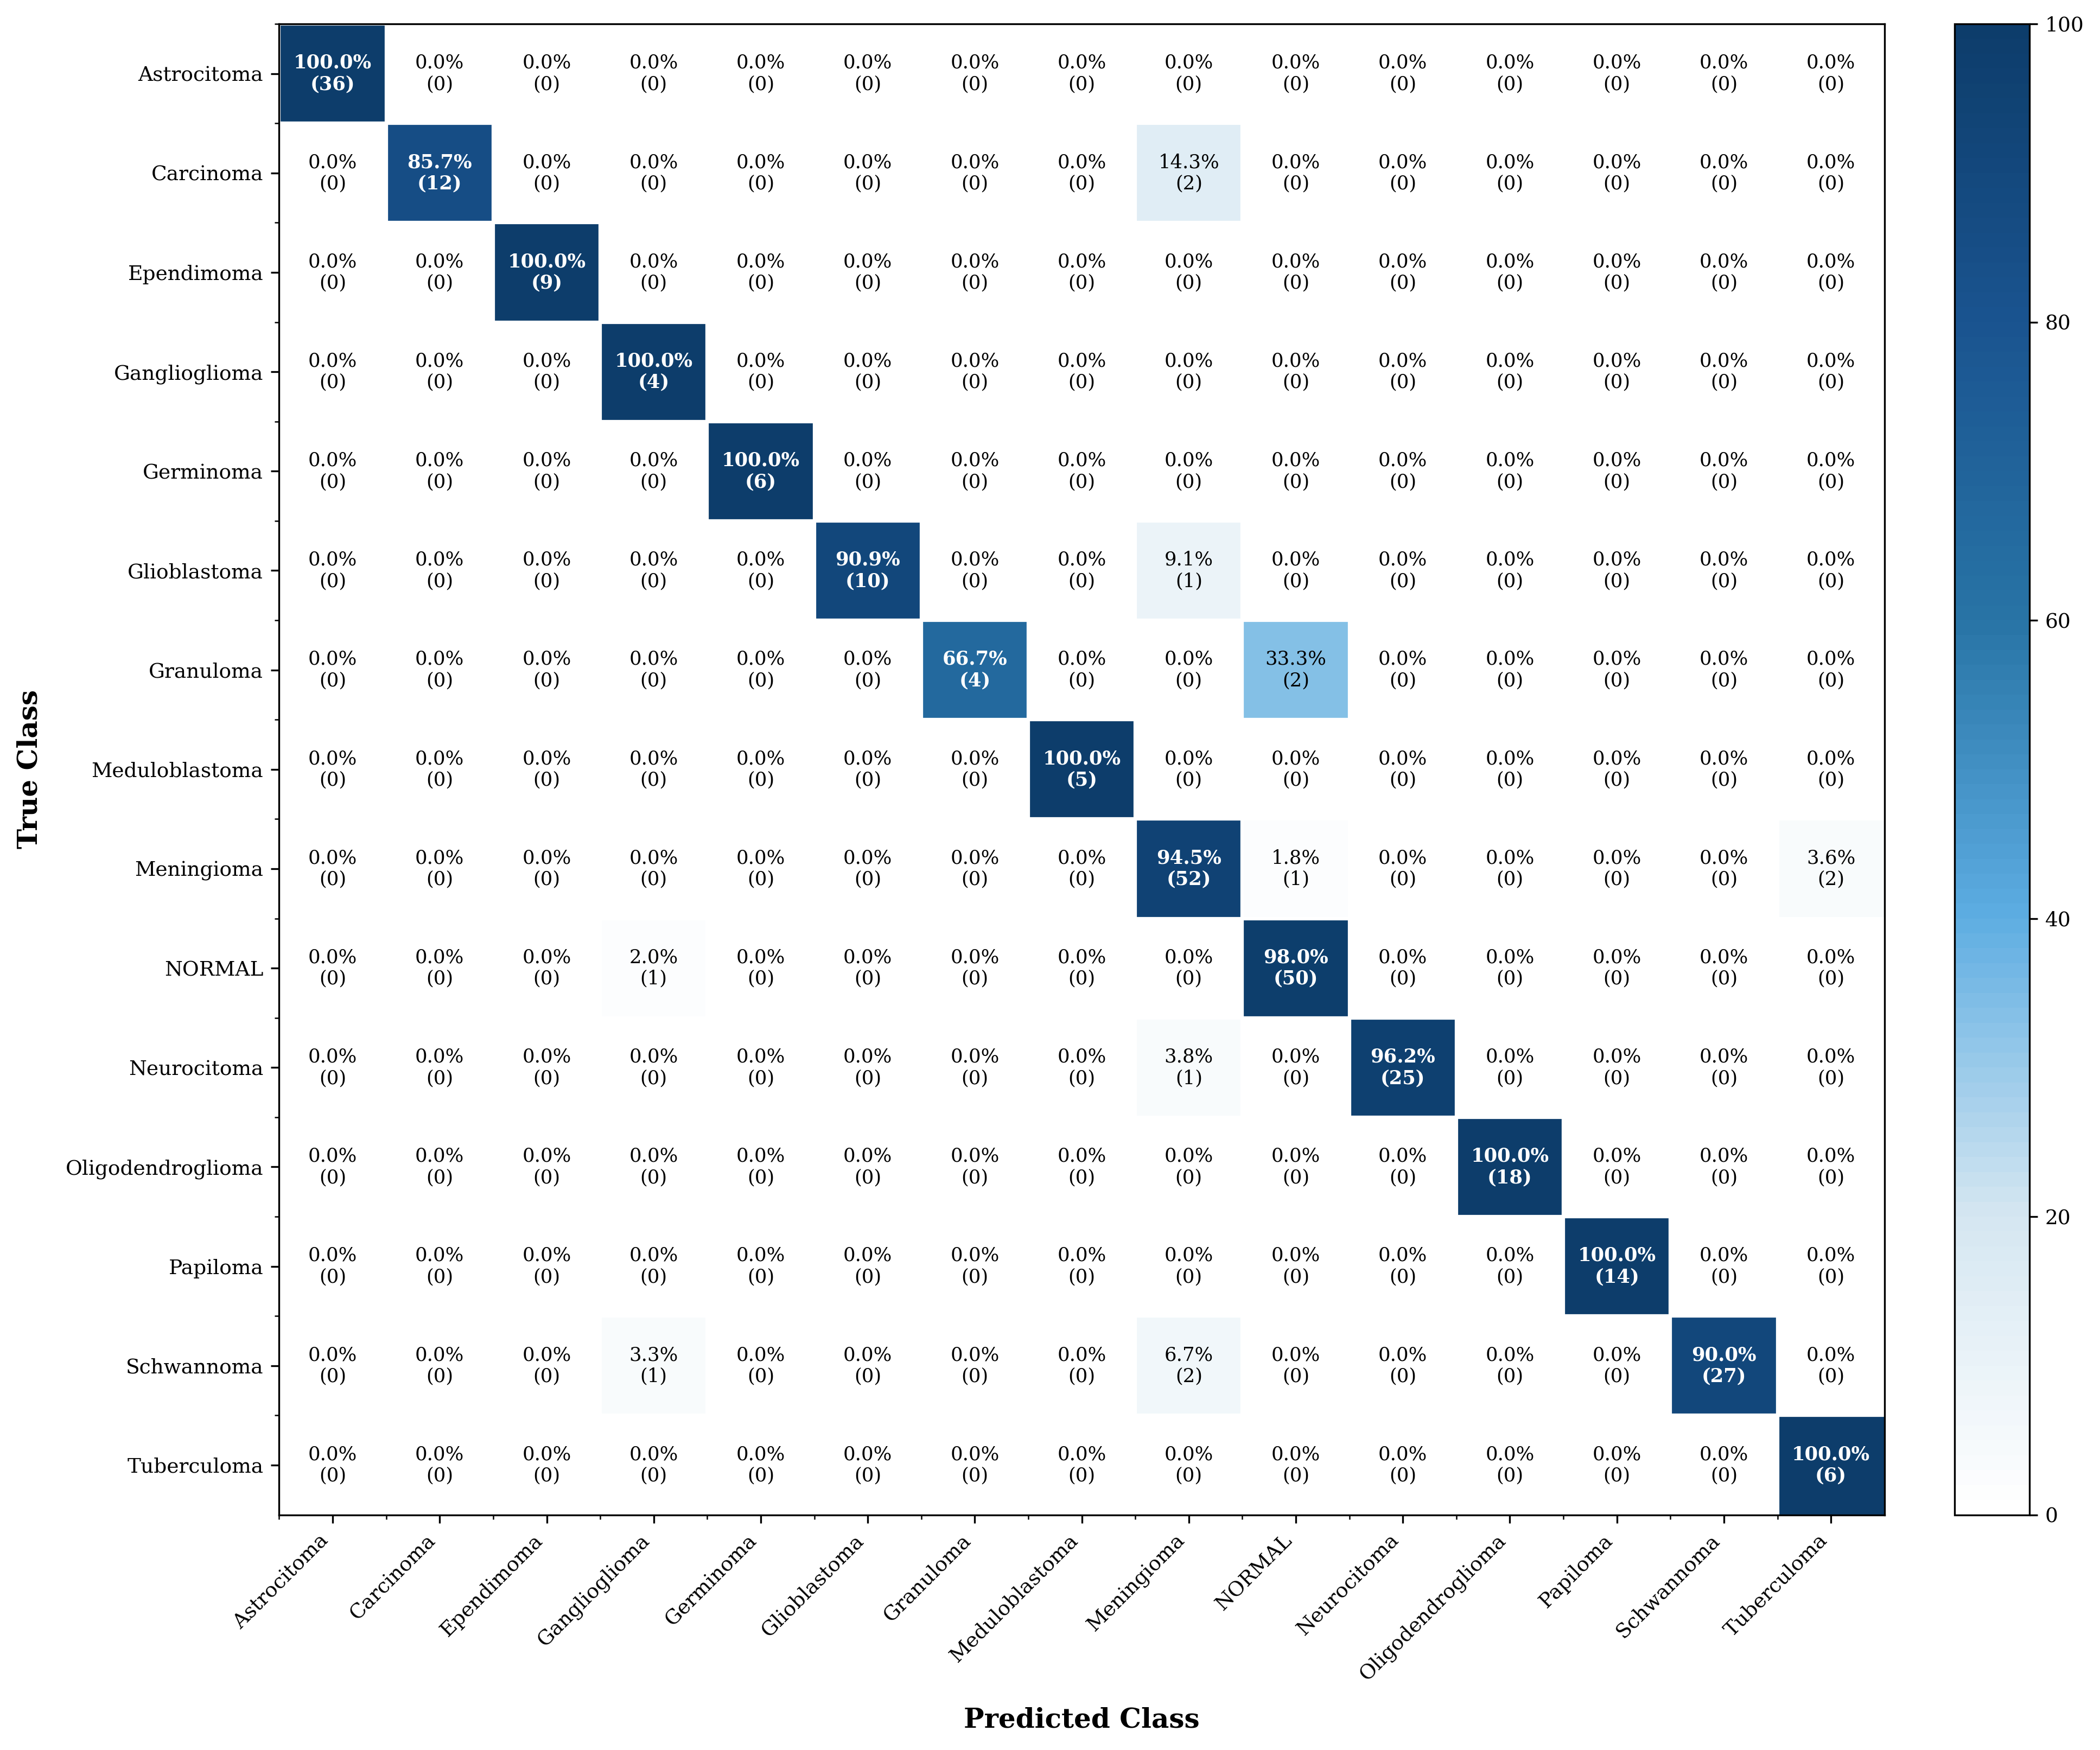

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

# ========== PUBLICATION-QUALITY SETTINGS ==========
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 12
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

# ------------------ USER INPUT ------------------
csv_path = r"/home/nirob/Desktop/Brain tumor mri /runs/Proposed Model/T1/seed24/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed24_VAL_confusion_matrix.csv"

# Put your class names here IN THE SAME ORDER as your label encoder / confusion matrix creation
CLASS_NAMES = [
    'Astrocitoma', 'Carcinoma', 'Ependimoma', 'Ganglioglioma', 'Germinoma',
    'Glioblastoma', 'Granuloma', 'Meduloblastoma', 'Meningioma', 'NORMAL',
    'Neurocitoma', 'Oligodendroglioma', 'Papiloma', 'Schwannoma', 'Tuberculoma'
]

SAVE_PDF = "/home/nirob/Desktop/Brain tumor mri /plots/T1/confusion_matrix_publication.pdf"
SAVE_PNG = "/home/nirob/Desktop/Brain tumor mri /plots/T1/confusion_matrix_publication.png"
# ------------------------------------------------

# Read CSV with NO headers/indices
cm_df = pd.read_csv(csv_path, header=None)
cm = cm_df.values.astype(float)

n = cm.shape[0]
if cm.shape[0] != cm.shape[1]:
    raise ValueError(f"Confusion matrix must be square. Got shape {cm.shape}")

if len(CLASS_NAMES) != n:
    raise ValueError(f"CLASS_NAMES has {len(CLASS_NAMES)} names, but confusion matrix is {n}x{n}.")

# Normalize row-wise (%), safe for zero rows
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0) * 100.0

# Custom colormap
colors_list = ['#ffffff', '#d4e6f1', '#5dade2', '#2874a6', '#1a5490', '#0d3d6b']
cmap_custom = LinearSegmentedColormap.from_list('custom_blues', colors_list, N=100)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_norm, cmap=cmap_custom, aspect='auto', vmin=0, vmax=100)

# Colorbar: keep ticks, remove label text
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("")  # removes "Classification Rate (%)"
cbar.ax.tick_params(labelsize=9)

# Cell annotations
for i in range(n):
    for j in range(n):
        val = cm_norm[i, j]
        cnt = cm[i, j]
        text_color = "white" if val > 50 else "black"
        weight = "bold" if i == j else "normal"
        ax.text(j, i, f"{val:.1f}%\n({int(cnt)})",
                ha="center", va="center", color=text_color, fontsize=8.5, weight=weight)

# Grid lines
ax.set_xticks(np.arange(n) - 0.5, minor=True)
ax.set_yticks(np.arange(n) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.5)

# Class names on both axes
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)

# Axis labels (keep if you want)
ax.set_xlabel("Predicted Class", fontweight="bold", fontsize=12, labelpad=10)
ax.set_ylabel("True Class", fontweight="bold", fontsize=12, labelpad=10)

# Remove any title
ax.set_title("")
fig.suptitle("")

plt.tight_layout()
plt.savefig(SAVE_PDF, dpi=300, bbox_inches="tight", transparent=True)
plt.savefig(SAVE_PNG, dpi=300, bbox_inches="tight", transparent=True)
plt.show()


# Merge CSV File for Mean STD

In [4]:
import os, re, glob
from pathlib import Path

import numpy as np
import pandas as pd

# =========================
# MANUAL INPUTS (EDIT THESE)
# =========================
pth1 = r"/home/nirob/Desktop/Brain tumor mri /diff_models"
pth2 = None
saved_pth = r"/home/nirob/Desktop/Brain tumor mri /diff_models"  # can be a DIRECTORY

# Enforce only these seeds (set None to keep all)
SEED_FILTER = [0, 24, 48]

# Optional: restrict to specific model folder names
MODEL_WHITELIST = {
    # "ConvNeXtV2-Atto",
    # "ConvNeXtV2-Tiny",
    # "DenseNet-121",
    "EfficientNet-B0",
    # "Inception-V3",
    # "MobileNetV3-L",
    # "VGG-16-BN",
    # "VGG-19-BN",
    # "Xception41",
    #"Proposed Model",
}
USE_MODEL_WHITELIST = True

# Known modalities (helps robust parsing if folder order varies)
KNOWN_MODALITIES = {"T1", "T1C+", "T2"}


# =========================
# HELPERS
# =========================
def discover_final_metrics_csvs(root: str):
    root = os.path.expanduser(root)
    if not root or not os.path.isdir(root):
        return []
    pats = [
        os.path.join(root, "**", "*_final_metrics.csv"),
        os.path.join(root, "**", "*final_metrics.csv"),
    ]
    files = []
    for p in pats:
        files.extend(glob.glob(p, recursive=True))
    files = [f for f in files if os.path.isfile(f)]
    return sorted(set(files))


def infer_seed(text: str):
    m = re.search(r"(?:seed[_=]?)(\d+)", text)
    return int(m.group(1)) if m else None


def parse_modality_model_seed_from_path(filepath: str):
    """
    Tries to parse:
      A) .../<modality>/<model>/seed_24/<file>
      B) .../<model>/<modality>/seed_24/<file>
    Returns (modality, model, seed)
    """
    norm = os.path.normpath(filepath)
    parts = norm.split(os.sep)

    seed_idx = None
    for i, p in enumerate(parts):
        if re.match(r"^seed[_=]?\d+$", p):
            seed_idx = i
            break

    if seed_idx is None:
        return None, None, infer_seed(filepath)

    seed = infer_seed(parts[seed_idx])

    # candidates around seed folder
    a = parts[seed_idx - 2] if seed_idx - 2 >= 0 else None  # could be modality or model
    b = parts[seed_idx - 1] if seed_idx - 1 >= 0 else None  # could be model or modality

    # Default assume: .../<modality>/<model>/seed_xx
    modality, model = a, b

    # If looks swapped: .../<model>/<modality>/seed_xx
    if (b in KNOWN_MODALITIES) and (a not in KNOWN_MODALITIES):
        modality, model = b, a

    return modality, model, seed


def safe_numeric(series: pd.Series):
    return pd.to_numeric(series, errors="coerce")


def mean_std_fmt(mean, std, decimals=3):
    if pd.isna(mean):
        return ""
    if pd.isna(std) or float(std) == 0.0:
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def resolve_save_path(saved_pth: str) -> Path:
    """
    If saved_pth is a directory (or has no .csv suffix), save a default csv inside it.
    """
    sp = Path(saved_pth)
    # treat as directory if:
    # - it exists and is a dir, OR
    # - it doesn't end with .csv (no suffix)
    if sp.exists() and sp.is_dir():
        out_dir = sp
        out_dir.mkdir(parents=True, exist_ok=True)
        return out_dir / "mean_std_by_modality_model.csv"

    if sp.suffix.lower() != ".csv":
        # assume user intended a directory
        out_dir = sp
        out_dir.mkdir(parents=True, exist_ok=True)
        return out_dir / "mean_std_by_modality_model.csv"

    sp.parent.mkdir(parents=True, exist_ok=True)
    return sp


# =========================
# MAIN
# =========================
files = []
files += discover_final_metrics_csvs(pth1)
#files += discover_final_metrics_csvs(pth2)
files = sorted(set(files))

if not files:
    raise FileNotFoundError(f"No *final_metrics.csv found under:\n- {pth1}\n- {pth2}")

rows = []
for f in files:
    modality, model, seed = parse_modality_model_seed_from_path(f)

    if USE_MODEL_WHITELIST and model is not None and model not in MODEL_WHITELIST:
        continue

    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f"[WARN] cannot read: {f}\n       {e}")
        continue

    if df.empty:
        continue

    df = df.copy()

    # Fill missing keys from path
    if "modality" not in df.columns or df["modality"].isna().all():
        df["modality"] = modality
    if "model" not in df.columns or df["model"].isna().all():
        df["model"] = model
    if "seed" not in df.columns or df["seed"].isna().all():
        df["seed"] = seed

    df["source_file"] = f
    rows.append(df)

if not rows:
    raise RuntimeError("No readable/non-empty final_metrics CSVs after filtering.")

big = pd.concat(rows, ignore_index=True)

# enforce seed filter
big["seed"] = safe_numeric(big["seed"])
if SEED_FILTER is not None:
    big = big[big["seed"].isin(SEED_FILTER)]

# ensure required keys exist
for k in ["modality", "model", "seed"]:
    if k not in big.columns:
        raise KeyError(f"Missing required column: {k}")

group_keys = ["modality", "model"]

# convert parseable object columns to numeric when possible (but keep known text/path cols)
NON_NUMERIC_COLS = {
    "modality", "model", "timm_id", "best_by", "meta_json",
    "epoch_log_csv", "val_confusion_csv", "val_confusion_norm_csv",
    "val_confusion_png", "val_arrays_npz", "val_calibration_bins_csv",
    "val_risk_coverage_csv", "val_rocpr_npz", "source_file"
}
for c in big.columns:
    if c in NON_NUMERIC_COLS:
        continue
    if big[c].dtype == object:
        conv = pd.to_numeric(big[c], errors="coerce")
        if conv.notna().mean() >= 0.8 and conv.notna().sum() > 0:
            big[c] = conv

# collapse duplicates if same (modality, model, seed) appears in both pth1 & pth2
# numeric -> mean within seed; non-numeric -> first non-null within seed
numeric_cols_all = [c for c in big.columns if pd.api.types.is_numeric_dtype(big[c]) and c not in ["seed"]]
other_cols_all = [c for c in big.columns if c not in group_keys + ["seed"] + numeric_cols_all]

agg = {}
for c in numeric_cols_all:
    agg[c] = "mean"
for c in other_cols_all:
    agg[c] = (lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan)

seed_level = (
    big.groupby(group_keys + ["seed"], dropna=False)
       .agg(agg)
       .reset_index()
)

# summarize across seeds per (modality, model)
numeric_cols = [c for c in seed_level.columns if c not in group_keys + ["seed"] and pd.api.types.is_numeric_dtype(seed_level[c])]
grp = seed_level.groupby(group_keys, dropna=False)

means = grp[numeric_cols].mean().add_suffix("_mean")
stds  = grp[numeric_cols].std(ddof=1).add_suffix("_std")

n_seeds = grp.size().rename("n_seeds")
seeds_list = grp["seed"].agg(lambda s: ",".join(map(str, sorted(set(s.dropna().astype(int).tolist()))))).rename("seeds")

files_list = (
    big.groupby(group_keys, dropna=False)["source_file"]
       .agg(lambda s: " | ".join(sorted(set(s.tolist()))))
       .rename("files")
)

out = pd.concat([means, stds, n_seeds, seeds_list, files_list], axis=1).reset_index()

# Add mean±std formatted columns for key metrics (you can extend this list)
key_cols = [
    "params_m", "ms_per_img", "throughput_img_s",
    "val_acc", "val_macro_f1", "val_auc_macro_ovr", "val_ece_15bins", "val_nll", "val_brier",
    "test_acc", "test_macro_f1", "test_auc_macro_ovr", "test_ece_15bins", "test_nll", "test_brier",
]
for c in key_cols:
    if f"{c}_mean" in out.columns:
        dec = 2 if c == "params_m" else (1 if c == "throughput_img_s" else (3 if c == "ms_per_img" else 3))
        out[f"{c}_mean±std"] = out.apply(
            lambda r: mean_std_fmt(r[f"{c}_mean"], r.get(f"{c}_std", np.nan), decimals=dec),
            axis=1
        )

# Save (handles directory vs file path)
save_file = resolve_save_path(saved_pth)
out.to_csv(save_file, index=False)
print(f"[OK] Saved: {save_file}")

# quick compact print
show_cols = [
    "modality", "model", "n_seeds", "seeds",
    "params_m_mean±std", "ms_per_img_mean±std", "throughput_img_s_mean±std",
    "val_acc_mean±std", "val_macro_f1_mean±std", "val_ece_15bins_mean±std"
]
show_cols = [c for c in show_cols if c in out.columns]
print(out[show_cols].sort_values(["modality", "model"]).to_string(index=False))


[OK] Saved: /home/nirob/Desktop/Brain tumor mri /diff_models/mean_std_by_modality_model.csv
modality                                                                                      model  n_seeds   seeds params_m_mean±std ms_per_img_mean±std throughput_img_s_mean±std val_acc_mean±std val_macro_f1_mean±std val_ece_15bins_mean±std
      T1                                                 STNROI+efficientnet_b0.ra4_e3600_r224_in1k        3 0,24,48              4.05       0.472 ± 0.018             2120.5 ± 80.8    0.960 ± 0.004         0.939 ± 0.004           0.038 ± 0.015
      T1 STNROI+efficientnet_b0.ra4_e3600_r224_in1k|pruned(Kmax=0,tau=0.7677773160959454,dyn=False)        3 0,24,48              4.05       0.193 ± 0.006            5189.0 ± 156.5    0.960 ± 0.004         0.939 ± 0.004           0.037 ± 0.017
    T1C+                                                 STNROI+efficientnet_b0.ra4_e3600_r224_in1k        3 0,24,48              4.05       0.478 ± 0.058            2113.6 ± 2

# ROI Regions

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
K-ROI visualizer + cropper (ALL VARIABLES EDITABLE IN CODE)

What it does:
- Selects RANDOM 20 images from IMAGE_DIR
- Saves selected image names to a list (txt + json)
- For each image:
    - Samples K ROIs with controllable ROI size
    - Draws ROIs in RED with controllable "boldness" (thickness + alpha + optional fill)
    - Saves ROI coordinates + ROI sizes in a list (JSON)
    - Crops and saves each ROI

Dependencies:
    pip install pillow
"""

import json
import random
from pathlib import Path
from typing import List, Tuple, Dict, Any
from PIL import Image, ImageDraw

# ============================================================
# ===================== EDIT SETTINGS HERE ====================
# ============================================================

# --- Input / Output ---
IMAGE_DIR   = Path(r"/home/nirob/Desktop/Brain tumor mri /dataset/data_split/train/T1C+/Astrocitoma")     # <-- change
OUT_DIR     = Path(r"/home/nirob/Desktop/Brain tumor mri /roi images")   # <-- change
NUM_IMAGES  = 20                                # random images to pick

# --- Randomness (set SEED=None for different results each run) ---
SEED = 42

# --- ROI settings ---
K = 3  # number of ROIs per image

ROI_MODE = "fixed"     # "fixed" or "random"

# If ROI_MODE == "fixed"
ROI_W = 220
ROI_H = 220

# If ROI_MODE == "random"
ROI_MIN_W = 80
ROI_MAX_W = 220
ROI_MIN_H = 80
ROI_MAX_H = 220

# Avoid overlap between ROIs (may be slower for large K / large ROI sizes)
AVOID_OVERLAP = False
MAX_TRIES_PER_ROI = 2000  # only used if AVOID_OVERLAP=True

# --- Draw controls (red boldness) ---
BORDER_THICKNESS = 6      # border thickness in pixels (bigger = bolder)
ALPHA_OUTLINE    = 1.0    # outline transparency in [0,1] (1=solid)

FILL_ROI   = True         # draw transparent fill inside ROI
ALPHA_FILL = 0.15         # fill transparency in [0,1]

# --- File types allowed ---
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# ============================================================
# =================== NO NEED TO EDIT BELOW ==================
# ============================================================

def list_images(image_dir: Path) -> List[Path]:
    paths = []
    for p in image_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            paths.append(p)
    return sorted(paths)

def clamp_roi_size(w: int, h: int, W: int, H: int) -> Tuple[int, int]:
    w = max(1, min(w, W))
    h = max(1, min(h, H))
    return w, h

def rects_intersect(a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]) -> bool:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    return not (ax2 <= bx1 or bx2 <= ax1 or ay2 <= by1 or by2 <= ay1)

def sample_rois(W: int, H: int) -> List[Dict[str, int]]:
    rois: List[Dict[str, int]] = []
    existing: List[Tuple[int, int, int, int]] = []

    for _ in range(K):
        placed = False
        tries = 0

        while not placed and tries < MAX_TRIES_PER_ROI:
            tries += 1

            if ROI_MODE == "fixed":
                w, h = clamp_roi_size(ROI_W, ROI_H, W, H)
            elif ROI_MODE == "random":
                w = random.randint(max(1, ROI_MIN_W), max(1, ROI_MAX_W))
                h = random.randint(max(1, ROI_MIN_H), max(1, ROI_MAX_H))
                w, h = clamp_roi_size(w, h, W, H)
            else:
                raise ValueError("ROI_MODE must be 'fixed' or 'random'")

            x = random.randint(0, max(0, W - w))
            y = random.randint(0, max(0, H - h))
            rect = (x, y, x + w, y + h)

            if AVOID_OVERLAP and any(rects_intersect(rect, r) for r in existing):
                continue

            rois.append({"x": x, "y": y, "w": w, "h": h, "x2": x + w, "y2": y + h})
            existing.append(rect)
            placed = True

        if not placed:
            # fallback (may overlap)
            if ROI_MODE == "fixed":
                w, h = clamp_roi_size(ROI_W, ROI_H, W, H)
            else:
                w, h = clamp_roi_size(ROI_MIN_W, ROI_MIN_H, W, H)
            x = random.randint(0, max(0, W - w))
            y = random.randint(0, max(0, H - h))
            rois.append({"x": x, "y": y, "w": w, "h": h, "x2": x + w, "y2": y + h})

    return rois

def draw_rois(img_rgb: Image.Image, rois: List[Dict[str, int]]) -> Image.Image:
    base = img_rgb.convert("RGBA")
    overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(overlay)

    outline_a = int(max(0.0, min(1.0, ALPHA_OUTLINE)) * 255)
    fill_a    = int(max(0.0, min(1.0, ALPHA_FILL)) * 255)

    for r in rois:
        x1, y1, x2, y2 = r["x"], r["y"], r["x2"], r["y2"]
        if FILL_ROI:
            d.rectangle([x1, y1, x2, y2], fill=(255, 0, 0, fill_a))
        d.rectangle([x1, y1, x2, y2], outline=(255, 0, 0, outline_a), width=max(1, BORDER_THICKNESS))

    return Image.alpha_composite(base, overlay).convert("RGB")

def run():
    if SEED is not None:
        random.seed(SEED)

    if not IMAGE_DIR.exists():
        raise SystemExit(f"IMAGE_DIR does not exist: {IMAGE_DIR}")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    all_imgs = list_images(IMAGE_DIR)
    if len(all_imgs) == 0:
        raise SystemExit(f"No images found in: {IMAGE_DIR} (exts: {sorted(IMG_EXTS)})")

    n = min(NUM_IMAGES, len(all_imgs))
    chosen = random.sample(all_imgs, n)

    chosen_names = [p.name for p in chosen]
    (OUT_DIR / "selected_images.txt").write_text("\n".join(chosen_names), encoding="utf-8")
    (OUT_DIR / "selected_images.json").write_text(json.dumps(chosen_names, indent=2), encoding="utf-8")

    marked_dir = OUT_DIR / "marked"
    crops_dir  = OUT_DIR / "crops"
    marked_dir.mkdir(exist_ok=True)
    crops_dir.mkdir(exist_ok=True)

    meta: Dict[str, Any] = {
        "settings": {
            "IMAGE_DIR": str(IMAGE_DIR),
            "OUT_DIR": str(OUT_DIR),
            "NUM_IMAGES": NUM_IMAGES,
            "SEED": SEED,
            "K": K,
            "ROI_MODE": ROI_MODE,
            "ROI_W": ROI_W,
            "ROI_H": ROI_H,
            "ROI_MIN_W": ROI_MIN_W,
            "ROI_MAX_W": ROI_MAX_W,
            "ROI_MIN_H": ROI_MIN_H,
            "ROI_MAX_H": ROI_MAX_H,
            "AVOID_OVERLAP": AVOID_OVERLAP,
            "MAX_TRIES_PER_ROI": MAX_TRIES_PER_ROI,
            "BORDER_THICKNESS": BORDER_THICKNESS,
            "ALPHA_OUTLINE": ALPHA_OUTLINE,
            "FILL_ROI": FILL_ROI,
            "ALPHA_FILL": ALPHA_FILL,
        },
        "selected_images": chosen_names,
        "per_image": []
    }

    for img_path in chosen:
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        rois = sample_rois(W, H)
        marked = draw_rois(img, rois)

        stem = img_path.stem
        marked_path = marked_dir / f"{stem}_k{K}_marked.png"
        marked.save(marked_path)

        per_img_crop_dir = crops_dir / stem
        per_img_crop_dir.mkdir(exist_ok=True)

        crops_info = []
        for i, r in enumerate(rois):
            x1, y1, x2, y2 = r["x"], r["y"], r["x2"], r["y2"]
            crop = img.crop((x1, y1, x2, y2))
            crop_path = per_img_crop_dir / f"roi_{i:02d}_x{x1}_y{y1}_w{r['w']}_h{r['h']}.png"
            crop.save(crop_path)

            crops_info.append({
                "roi_id": i,
                "coords": [x1, y1, x2, y2],
                "size": [r["w"], r["h"]],
                "crop_path": str(crop_path),
            })

        meta["per_image"].append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "image_size": [W, H],
            "marked_path": str(marked_path),
            "roi_coords_list": [[r["x"], r["y"], r["x2"], r["y2"]] for r in rois],
            "roi_size_list": [[r["w"], r["h"]] for r in rois],
            "crops": crops_info,
        })

    (OUT_DIR / "roi_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

    print("✅ Done.")
    print(f"Output folder: {OUT_DIR}")
    print(f"- selected_images.txt / .json")
    print(f"- marked/   (ROI drawn images)")
    print(f"- crops/    (cropped ROI patches)")
    print(f"- roi_metadata.json (coords + sizes + paths)")


if __name__ == "__main__":
    run()


✅ Done.
Output folder: /home/nirob/Desktop/Brain tumor mri /roi images
- selected_images.txt / .json
- marked/   (ROI drawn images)
- crops/    (cropped ROI patches)
- roi_metadata.json (coords + sizes + paths)


# Comet Plot

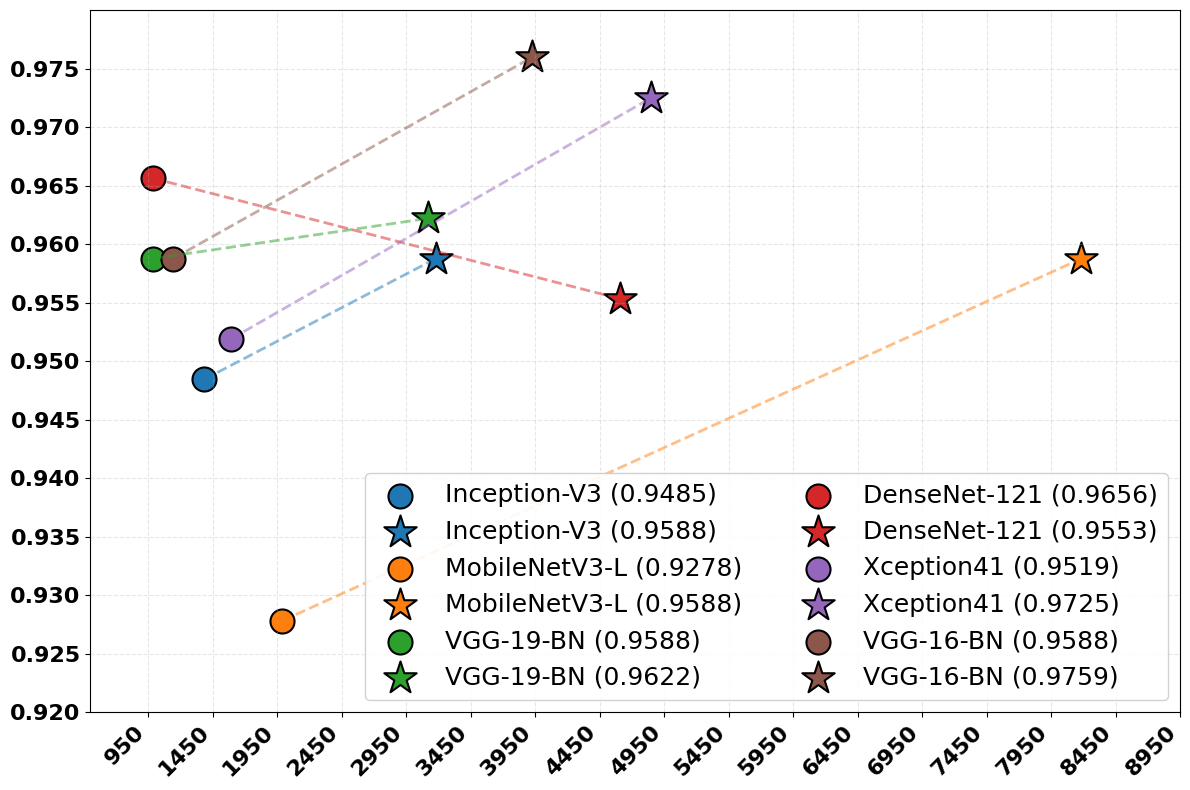

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Inception-V3', 'MobileNetV3-L', 'VGG-19-BN', 'DenseNet-121', 'Xception41', 'VGG-16-BN']

# Raw values (dot)
throughput_raw = [1384.956372, 1989.600855, 985.6280961, 983.0444593, 1590.187414, 1143.340424]
accuracy_raw = [0.9484536082, 0.9278350515, 0.9587628866, 0.9656357388, 0.9518900344, 0.9587628866]

# Pruned values (star)
throughput_pruned = [3179.129841, 8185.281928, 3119.47663, 4609.25354, 4850.831918, 3923.50947]
accuracy_pruned = [0.9587628866, 0.9587628866, 0.9621993127, 0.9553264605, 0.9725085911, 0.9759450172]

# Colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Create figure
plt.figure(figsize=(12, 8))

# Plot raw values (dots) and pruned values (stars)
for i, model in enumerate(models):
    # Raw values - dot
    plt.scatter(throughput_raw[i], accuracy_raw[i], 
               color=colors[i], marker='o', s=300, 
               label=f'{model} ({accuracy_raw[i]:.4f})', edgecolors='black', linewidth=1.5)
    
    # Pruned values - star
    plt.scatter(throughput_pruned[i], accuracy_pruned[i], 
               color=colors[i], marker='*', s=600, 
               label=f'{model} ({accuracy_pruned[i]:.4f})', edgecolors='black', linewidth=1.5)
    
    # Draw connecting line between raw and pruned
    plt.plot([throughput_raw[i], throughput_pruned[i]], 
            [accuracy_raw[i], accuracy_pruned[i]], 
            color=colors[i], linestyle='--', alpha=0.5, linewidth=2)

# Set axis limits and labels
plt.xlim(500, 8500)
plt.xticks(np.arange(950, 9000, 500), fontsize=16, rotation=45, ha='right',fontweight='bold')
plt.ylim(0.92, 0.98)
plt.yticks(np.arange(0.92, 0.98, 0.005), fontsize=16,fontweight='bold')

# plt.xlabel('Throughput (img/s)', fontsize=14, fontweight='bold')
# plt.ylabel('Validation Accuracy', fontsize=14, fontweight='bold')

# Grid
plt.grid(True, alpha=0.3, linestyle='--')

# Legend
plt.legend(fontsize=18, loc='lower right', framealpha=0.9, ncol=2)

# Tight layout
plt.tight_layout()

# Show plot
plt.show()

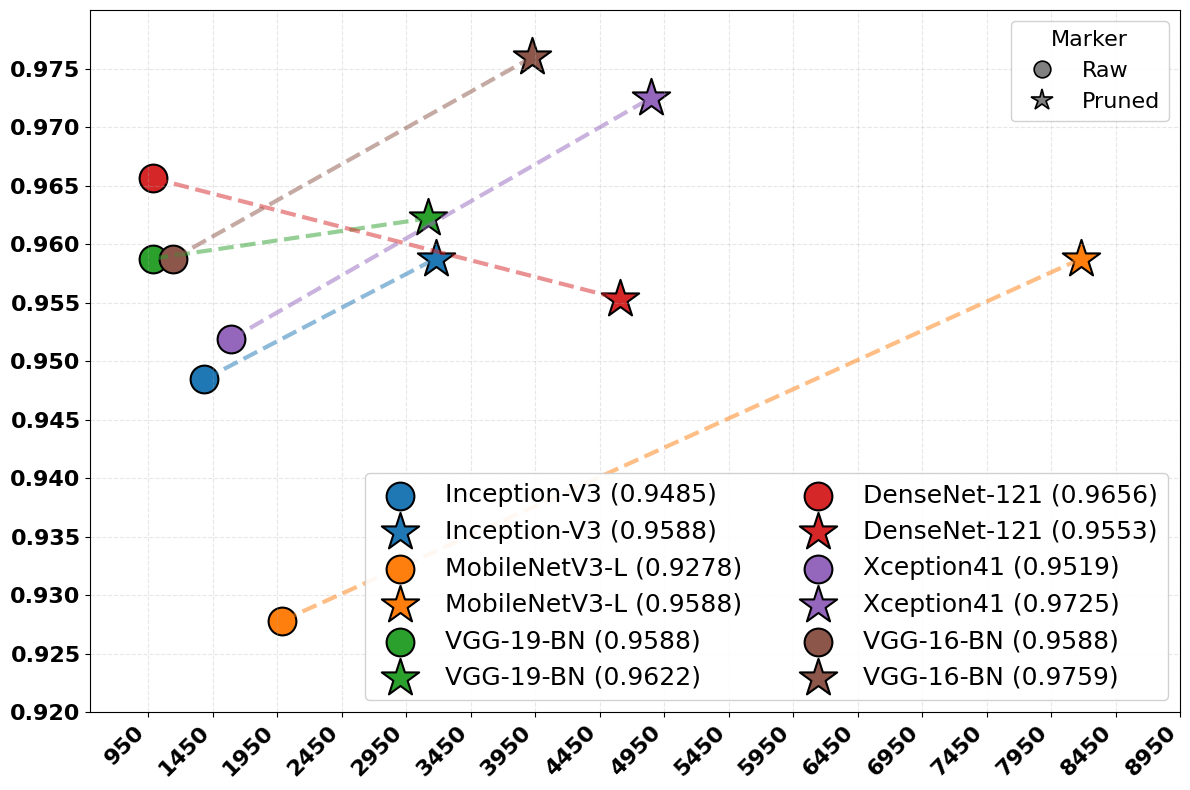

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Data
models = ['Inception-V3', 'MobileNetV3-L', 'VGG-19-BN', 'DenseNet-121', 'Xception41', 'VGG-16-BN']

# Raw values (dot)
throughput_raw = [1384.956372, 1989.600855, 985.6280961, 983.0444593, 1590.187414, 1143.340424]
accuracy_raw = [0.9484536082, 0.9278350515, 0.9587628866, 0.9656357388, 0.9518900344, 0.9587628866]

# Pruned values (star)
throughput_pruned = [3179.129841, 8185.281928, 3119.47663, 4609.25354, 4850.831918, 3923.50947]
accuracy_pruned = [0.9587628866, 0.9587628866, 0.9621993127, 0.9553264605, 0.9725085911, 0.9759450172]

# Colors for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(12, 8))

for i, model in enumerate(models):
    plt.scatter(throughput_raw[i], accuracy_raw[i],
                color=colors[i], marker='o', s=400,
                label=f'{model} ({accuracy_raw[i]:.4f})', edgecolors='black', linewidth=1.5)

    plt.scatter(throughput_pruned[i], accuracy_pruned[i],
                color=colors[i], marker='*', s=800,
                label=f'{model} ({accuracy_pruned[i]:.4f})', edgecolors='black', linewidth=1.5)

    plt.plot([throughput_raw[i], throughput_pruned[i]],
             [accuracy_raw[i], accuracy_pruned[i]],
             color=colors[i], linestyle='--', alpha=0.5, linewidth=3)

# Axis formatting
plt.xlim(500, 8500)
plt.xticks(np.arange(950, 9000, 500), fontsize=16, rotation=45, ha='right', fontweight='bold')
plt.ylim(0.92, 0.98)
plt.yticks(np.arange(0.92, 0.98, 0.005), fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')

# --- Main legend (models) ---
leg_models = plt.legend(fontsize=18, loc='lower right', framealpha=0.9, ncol=2)

# --- Footer legend (marker meaning) ---
marker_handles = [
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=12, markeredgecolor='black', markeredgewidth=1.2, label='Raw'),
    Line2D([0], [0], marker='*', color='gray', linestyle='None',
           markersize=16, markeredgecolor='black', markeredgewidth=1.2, label='Pruned'),
]

# Keep first legend and add a second one
plt.gca().add_artist(leg_models)

plt.legend(handles=marker_handles, fontsize=16, loc='upper right',
           framealpha=0.9, title="Marker", title_fontsize=16)

plt.tight_layout()
plt.show()


In [1]:

import torch
ckpt = "/home/nirob/Desktop/Brain tumor mri /runs/Proposed Model/T2/seed0/STNROI+convnextv2_tiny.fcmae_ft_in22k_in1k_seed0_best.pth"
sd = torch.load(ckpt, map_location="cpu")
if isinstance(sd, dict) and "state_dict" in sd:
    sd = sd["state_dict"]

K_rois = sd["roi_net.gate_logits.bias"].numel()
feat_dim = sd["attn_fc.weight"].shape[1]
print("K_rois in ckpt:", K_rois)
print("Backbone feat_dim in ckpt:", feat_dim)

# show some backbone keys to help identify architecture family
bk = [k for k in sd.keys() if k.startswith("backbone.")]
print("Example backbone keys:")
for k in bk[:25]:
    print(" ", k)



K_rois in ckpt: 4
Backbone feat_dim in ckpt: 768
Example backbone keys:
  backbone.stem.0.weight
  backbone.stem.0.bias
  backbone.stem.1.weight
  backbone.stem.1.bias
  backbone.stages.0.blocks.0.conv_dw.weight
  backbone.stages.0.blocks.0.conv_dw.bias
  backbone.stages.0.blocks.0.norm.weight
  backbone.stages.0.blocks.0.norm.bias
  backbone.stages.0.blocks.0.mlp.fc1.weight
  backbone.stages.0.blocks.0.mlp.fc1.bias
  backbone.stages.0.blocks.0.mlp.grn.weight
  backbone.stages.0.blocks.0.mlp.grn.bias
  backbone.stages.0.blocks.0.mlp.fc2.weight
  backbone.stages.0.blocks.0.mlp.fc2.bias
  backbone.stages.0.blocks.1.conv_dw.weight
  backbone.stages.0.blocks.1.conv_dw.bias
  backbone.stages.0.blocks.1.norm.weight
  backbone.stages.0.blocks.1.norm.bias
  backbone.stages.0.blocks.1.mlp.fc1.weight
  backbone.stages.0.blocks.1.mlp.fc1.bias
  backbone.stages.0.blocks.1.mlp.grn.weight
  backbone.stages.0.blocks.1.mlp.grn.bias
  backbone.stages.0.blocks.1.mlp.fc2.weight
  backbone.stages.0.blocks

# Heatmap 

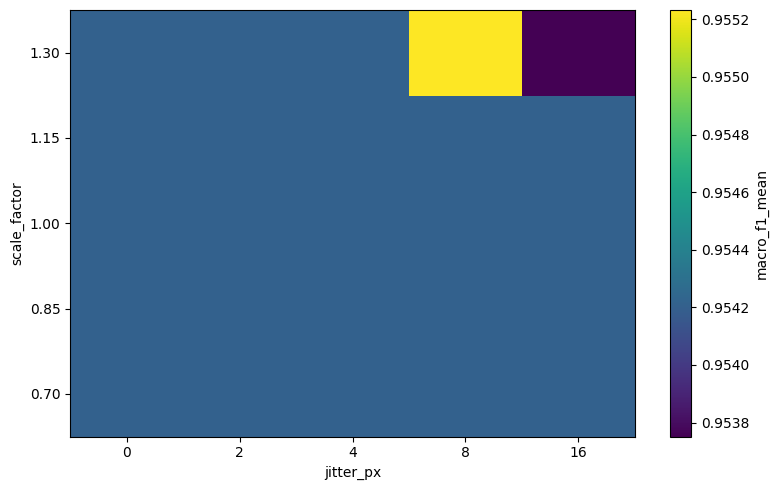

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Point this to your file
csv_path = r"/home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/roi_robustness_aggregated.csv"

# 2) Load + pivot into a (scale_factor × jitter_px) grid
df = pd.read_csv(csv_path)

# choose what you want to plot (examples: "macro_f1_mean", "ece_15bins_mean", "nll_mean", "acc_mean")
metric = "macro_f1_mean"

heat = df.pivot(index="scale_factor", columns="jitter_px", values=metric)
heat = heat.sort_index().sort_index(axis=1)

# 3) Plot heatmap (basic; you can style later)
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat.values, aspect="auto", origin="lower")  # style (cmap, etc.) later

ax.set_xlabel("jitter_px")
ax.set_ylabel("scale_factor")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_yticks(np.arange(len(heat.index)))
ax.set_xticklabels(heat.columns.tolist())
ax.set_yticklabels([f"{v:.2f}" for v in heat.index.tolist()])

fig.colorbar(im, ax=ax, label=metric)
plt.tight_layout()

# 4) Save (optional)
out_png = "heatmap_macro_f1_mean.png"
plt.savefig(out_png, dpi=300)
plt.show()


In [3]:
#!/usr/bin/env python3
"""
Generate publication-ready heatmaps for ROI robustness experiment.

Creates multiple visualization options:
1. Single heatmap (Accuracy only)
2. Multi-panel heatmap (Accuracy, ECE, NLL, Macro-F1)
3. Heatmap with annotations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set publication-quality defaults
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts
plt.rcParams['ps.fonttype'] = 42

def load_and_pivot(csv_path, metric='acc_mean'):
    """Load CSV and create pivot table for heatmap."""
    df = pd.read_csv(csv_path)
    
    # Convert to percentage if accuracy
    if 'acc' in metric:
        df[metric] = df[metric] * 100
    
    # Create pivot table
    pivot = df.pivot(index='scale_factor', columns='jitter_px', values=metric)
    
    # Sort by scale (descending) and jitter (ascending)
    pivot = pivot.sort_index(ascending=False)
    pivot = pivot[sorted(pivot.columns)]
    
    return pivot, df

def plot_single_heatmap(data, metric_name, output_path, 
                        cmap='RdYlGn', vmin=None, vmax=None,
                        fmt='.2f', cbar_label=None):
    """
    Create a single heatmap with clean styling.
    
    Parameters:
    -----------
    data : DataFrame
        Pivot table with scale_factor as index, jitter_px as columns
    metric_name : str
        Display name for the metric
    output_path : Path
        Where to save the figure
    cmap : str
        Colormap name
    vmin, vmax : float
        Color scale limits
    fmt : str
        Annotation format
    cbar_label : str
        Colorbar label (defaults to metric_name)
    """
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    
    # Create heatmap
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={'label': cbar_label or metric_name, 'shrink': 0.8},
        linewidths=0.5,
        linecolor='white',
        square=False,
        ax=ax
    )
    
    # Style axes
    ax.set_xlabel('Position Jitter (pixels)', fontweight='bold')
    ax.set_ylabel('ROI Scale Factor', fontweight='bold')
    ax.set_title(f'{metric_name} under ROI Perturbations', fontweight='bold', pad=15)
    
    # Rotate labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def plot_multi_panel_heatmap(csv_path, output_path):
    """
    Create a 2x2 panel with Accuracy, Macro-F1, ECE, and NLL.
    """
    metrics = {
        'acc_mean': {'name': 'Accuracy (%)', 'cmap': 'RdYlGn', 'fmt': '.2f', 
                     'vmin': 95, 'vmax': 98},
        'macro_f1_mean': {'name': 'Macro F1-Score', 'cmap': 'RdYlGn', 'fmt': '.4f',
                          'vmin': 0.95, 'vmax': 0.96},
        'ece_15bins_mean': {'name': 'ECE (15 bins)', 'cmap': 'RdYlGn_r', 'fmt': '.4f',
                            'vmin': 0.050, 'vmax': 0.053},
        'nll_mean': {'name': 'Negative Log-Likelihood', 'cmap': 'RdYlGn_r', 'fmt': '.4f',
                     'vmin': 0.157, 'vmax': 0.159},
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=300)
    axes = axes.flatten()
    
    for idx, (metric_key, config) in enumerate(metrics.items()):
        ax = axes[idx]
        
        # Load and pivot data
        pivot, _ = load_and_pivot(csv_path, metric=metric_key)
        
        # Create heatmap
        sns.heatmap(
            pivot,
            annot=True,
            fmt=config['fmt'],
            cmap=config['cmap'],
            vmin=config['vmin'],
            vmax=config['vmax'],
            cbar_kws={'label': config['name'], 'shrink': 0.9},
            linewidths=0.5,
            linecolor='white',
            square=False,
            ax=ax
        )
        
        # Style
        ax.set_xlabel('Position Jitter (pixels)', fontweight='bold')
        ax.set_ylabel('ROI Scale Factor', fontweight='bold')
        ax.set_title(f"({chr(97+idx)}) {config['name']}", fontweight='bold', 
                     loc='left', pad=10)
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    # plt.suptitle('Robustness to ROI Size and Position Perturbations', 
    #              fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def plot_single_with_std(csv_path, output_path):
    """
    Create a single heatmap with std as error annotations.
    Shows: mean ± std
    """
    df = pd.read_csv(csv_path)
    
    # Convert to percentage
    df['acc_mean'] = df['acc_mean'] * 100
    df['acc_std'] = df['acc_std'] * 100
    
    # Create pivot tables
    pivot_mean = df.pivot(index='scale_factor', columns='jitter_px', values='acc_mean')
    pivot_std = df.pivot(index='scale_factor', columns='jitter_px', values='acc_std')
    
    # Sort
    pivot_mean = pivot_mean.sort_index(ascending=False)
    pivot_mean = pivot_mean[sorted(pivot_mean.columns)]
    pivot_std = pivot_std.sort_index(ascending=False)
    pivot_std = pivot_std[sorted(pivot_std.columns)]
    
    # Create annotation matrix
    annot_data = np.empty_like(pivot_mean, dtype=object)
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            mean_val = pivot_mean.iloc[i, j]
            std_val = pivot_std.iloc[i, j]
            if std_val < 0.01:  # std is essentially zero
                annot_data[i, j] = f"{mean_val:.2f}"
            else:
                annot_data[i, j] = f"{mean_val:.2f}\n±{std_val:.2f}"
    
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
    
    sns.heatmap(
        pivot_mean,
        annot=annot_data,
        fmt='',
        cmap='RdYlGn',
        vmin=95,
        vmax=98,
        cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
        linewidths=0.5,
        linecolor='white',
        square=False,
        ax=ax
    )
    
    ax.set_xlabel('Position Jitter (pixels)', fontweight='bold')
    ax.set_ylabel('ROI Scale Factor', fontweight='bold')
    ax.set_title('Accuracy (mean ± std) under ROI Perturbations', 
                 fontweight='bold', pad=15)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def plot_difference_from_baseline(csv_path, output_path):
    """
    Plot difference from baseline (scale=1.0, jitter=0).
    Shows how much performance degrades from optimal.
    """
    df = pd.read_csv(csv_path)
    df['acc_mean'] = df['acc_mean'] * 100
    
    # Get baseline value
    baseline = df[(df['scale_factor'] == 1.0) & (df['jitter_px'] == 0)]['acc_mean'].values[0]
    
    # Calculate difference
    df['acc_diff'] = df['acc_mean'] - baseline
    
    # Pivot
    pivot = df.pivot(index='scale_factor', columns='jitter_px', values='acc_diff')
    pivot = pivot.sort_index(ascending=False)
    pivot = pivot[sorted(pivot.columns)]
    
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    
    # Use diverging colormap centered at 0
    max_abs = max(abs(pivot.min().min()), abs(pivot.max().max()))
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',  # Red = worse, Blue = better
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        cbar_kws={'label': 'Accuracy Change (%)', 'shrink': 0.8},
        linewidths=0.5,
        linecolor='white',
        square=False,
        ax=ax
    )
    
    ax.set_xlabel('Position Jitter (pixels)', fontweight='bold')
    ax.set_ylabel('ROI Scale Factor', fontweight='bold')
    ax.set_title(f'Accuracy Change from Baseline (scale=1.0, jitter=0)\nBaseline: {baseline:.2f}%', 
                 fontweight='bold', pad=15)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def create_summary_table(csv_path, output_path):
    """
    Create a summary table showing range of values for each metric.
    """
    df = pd.read_csv(csv_path)
    
    metrics = {
        'Accuracy (%)': 'acc_mean',
        'Macro F1': 'macro_f1_mean',
        'ECE': 'ece_15bins_mean',
        'NLL': 'nll_mean',
    }
    
    summary = []
    for display_name, col in metrics.items():
        values = df[col].values
        if 'acc' in col.lower():
            values = values * 100
        
        summary.append({
            'Metric': display_name,
            'Min': f"{values.min():.4f}",
            'Max': f"{values.max():.4f}",
            'Range': f"{values.max() - values.min():.4f}",
            'Mean': f"{values.mean():.4f}",
            'Std': f"{values.std():.4f}",
        })
    
    summary_df = pd.DataFrame(summary)
    
    # Save as CSV
    summary_df.to_csv(output_path, index=False)
    print(f"✓ Saved summary table: {output_path}")
    
    return summary_df

def main():
    # Input/output paths
    csv_path = Path("/home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/roi_robustness_aggregated.csv")
    out_dir = Path("/home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results")
    out_dir.mkdir(exist_ok=True, parents=True)
    
    print("="*60)
    print("Generating ROI Robustness Heatmaps")
    print("="*60)
    
    # 1. Single heatmap - Accuracy only (MAIN FIGURE)
    print("\n[1/6] Creating main accuracy heatmap...")
    pivot_acc, df = load_and_pivot(csv_path, metric='acc_mean')
    plot_single_heatmap(
        pivot_acc,
        metric_name='Accuracy (%)',
        output_path=out_dir / 'heatmap_accuracy.png',
        cmap='RdYlGn',
        vmin=95,
        vmax=98,
        fmt='.2f'
    )
    
    # Also save as PDF for publication
    plot_single_heatmap(
        pivot_acc,
        metric_name='Accuracy (%)',
        output_path=out_dir / 'heatmap_accuracy.pdf',
        cmap='RdYlGn',
        vmin=95,
        vmax=98,
        fmt='.2f'
    )
    
    # 2. Multi-panel heatmap (4 metrics)
    print("\n[2/6] Creating multi-panel heatmap...")
    plot_multi_panel_heatmap(csv_path, out_dir / 'heatmap_multi_panel.png')
    plot_multi_panel_heatmap(csv_path, out_dir / 'heatmap_multi_panel.pdf')
    
    # 3. Accuracy with std annotations
    print("\n[3/6] Creating accuracy heatmap with std...")
    plot_single_with_std(csv_path, out_dir / 'heatmap_accuracy_with_std.png')
    plot_single_with_std(csv_path, out_dir / 'heatmap_accuracy_with_std.pdf')
    
    # 4. Difference from baseline
    print("\n[4/6] Creating difference-from-baseline heatmap...")
    plot_difference_from_baseline(csv_path, out_dir / 'heatmap_accuracy_difference.png')
    plot_difference_from_baseline(csv_path, out_dir / 'heatmap_accuracy_difference.pdf')
    
    # 5. ECE heatmap (for calibration discussion)
    print("\n[5/6] Creating ECE heatmap...")
    pivot_ece, _ = load_and_pivot(csv_path, metric='ece_15bins_mean')
    plot_single_heatmap(
        pivot_ece,
        metric_name='Expected Calibration Error (ECE)',
        output_path=out_dir / 'heatmap_ece.png',
        cmap='RdYlGn_r',  # Reversed: lower is better
        vmin=0.050,
        vmax=0.053,
        fmt='.4f'
    )
    
    # 6. Summary statistics
    print("\n[6/6] Creating summary table...")
    summary = create_summary_table(csv_path, out_dir / 'robustness_summary_stats.csv')
    
    print("\n" + "="*60)
    print("Summary Statistics:")
    print("="*60)
    print(summary.to_string(index=False))
    
    print("\n" + "="*60)
    print("All figures saved to:", out_dir)
    print("="*60)
    
    print("\n📊 Recommended for paper:")
    print("  - Main text: heatmap_accuracy.pdf (single, clean)")
    print("  - Supplement: heatmap_multi_panel.pdf (comprehensive)")
    print("  - Optional: heatmap_accuracy_with_std.pdf (shows variance)")

if __name__ == "__main__":
    main()

Generating ROI Robustness Heatmaps

[1/6] Creating main accuracy heatmap...
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_accuracy.png
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_accuracy.pdf

[2/6] Creating multi-panel heatmap...
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_multi_panel.png
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_multi_panel.pdf

[3/6] Creating accuracy heatmap with std...
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_accuracy_with_std.png
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_accuracy_with_std.pdf

[4/6] Creating difference-from-baseline heatmap...
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/roi_jitter_results/heatmap_accuracy_difference.png
✓ Saved: /home/nirob/Desktop/Brain tumor mri /plots/jitter/r